# 2452769 幸可函 课程设计三实验报告

### (1) 使用A*和BFS算法，对起点到终点进行可视化搜索。并对两种算法流程、算法原理详细说明。

#### 1.导入（1）所需库

In [3]:
import numpy as np #用于表示二维栅格地图
import matplotlib.pyplot as plt #用于绘制地图、搜索过程和最终路径
from collections import deque #用于 BFS 队列
import heapq #用于 A* 的优先队列；
import time #用于动态可视化展示
from IPython.display import clear_output #用于动态可视化展示

#### 2. 问题建模
将机器人避障寻径问题建模为一个图搜索问题：

- 状态：机器人当前所在的格子坐标 `(row, col)`
- 初始状态：起点 `S`
- 目标状态：终点 `E`
- 动作：向上、下、左、右移动一格
- 状态转移：移动到相邻且合法的格子
- 路径代价：每移动一步代价为 1
- 障碍物：不可通行的格子

用二维矩阵表示地图：

- 0 表示可通行区域
- 1 表示障碍物

In [8]:
grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0]
]) #地图，1 代表障碍

#规定左上角为(0, 0)
#向下是x轴正方向，row 增大
#向右是y轴正方向，col 增大
#坐标写作：(row, col)

start = (2, 3) #机器人起点
goal = (4, 7) #机器人终点

grid

array([[0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 1, 1, 0, 0, 0],
       [0, 1, 0, 0, 1, 0, 0, 0],
       [0, 1, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 1, 1, 1, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0]])

#### 2.绘制地图

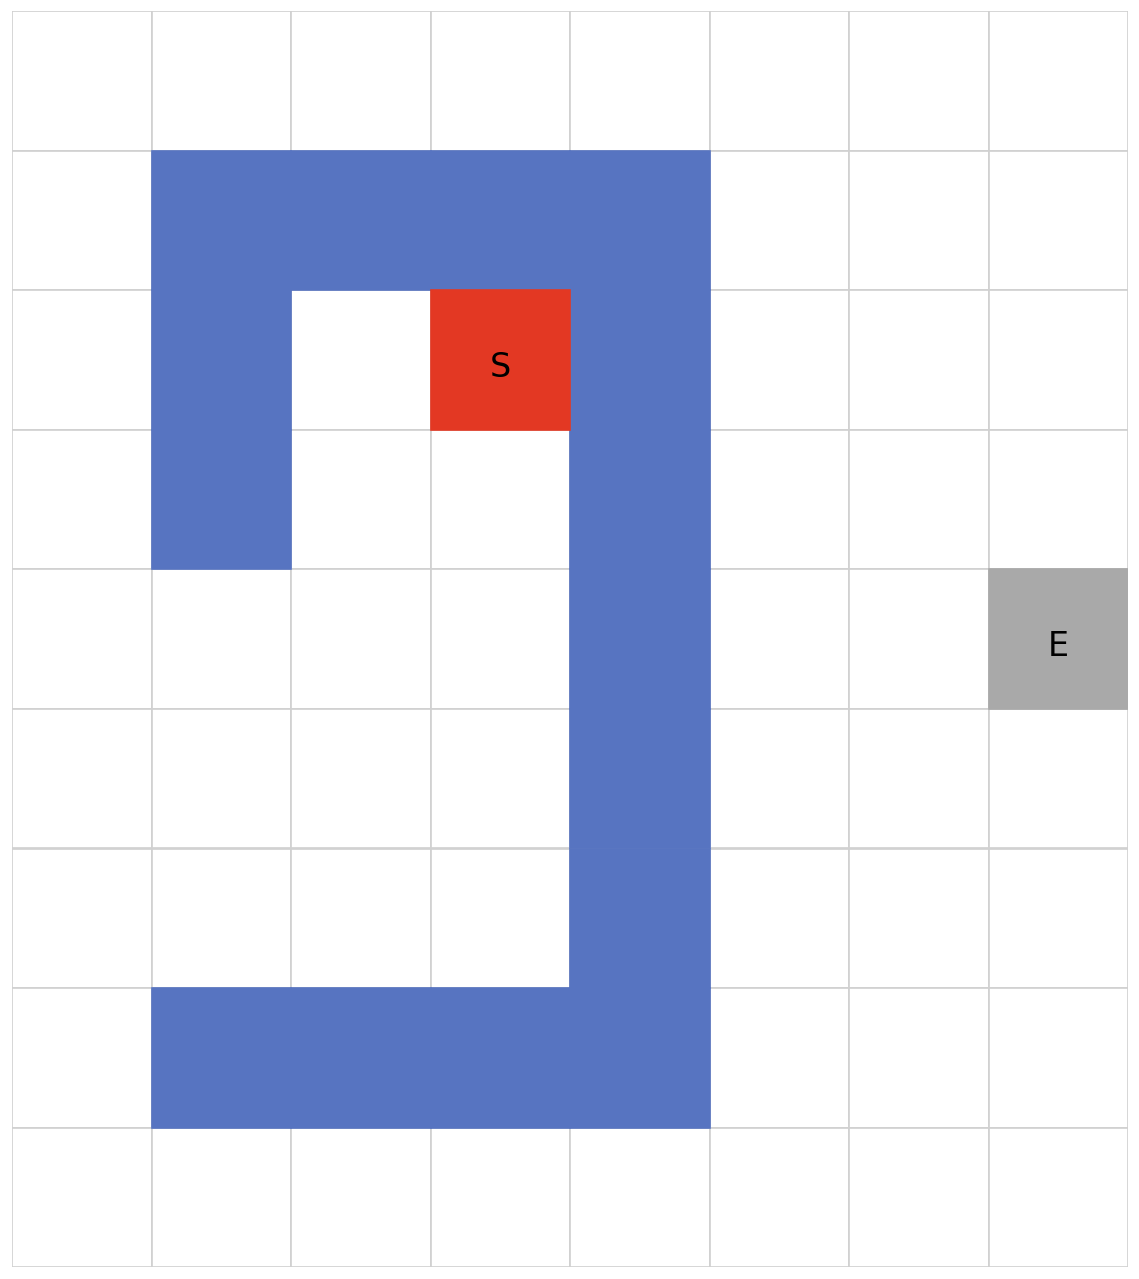

In [9]:
def draw_grid(grid, start, goal, visited=None, path=None, obstacle_color='#5774C1', start_color='#E33823', goal_color='#A9A9A9', grid_color='#D0D0D0', bg_color='white'):
    """绘制与示意图同风格的栅格地图。

    坐标约定：
    - (row, col)
    - 左上角为 (0, 0)
    - row 向下增大，col 向右增大
    """
    rows, cols = grid.shape
    fig, ax = plt.subplots(figsize=(cols * 1.2, rows * 1.2), dpi=120)
    ax.set_facecolor(bg_color)

    # 先画网格底色和网格线
    for r in range(rows):
        for c in range(cols):
            rect = plt.Rectangle((c, r), 1, 1, facecolor='white', edgecolor=grid_color, linewidth=1)
            ax.add_patch(rect)

    # 画障碍物
    for r in range(rows):
        for c in range(cols):
            if grid[r, c] == 1:
                rect = plt.Rectangle((c, r), 1, 1, facecolor=obstacle_color, edgecolor=obstacle_color, linewidth=1)
                ax.add_patch(rect)
    
    # 绘制访问过的节点
    if visited is not None:
            for r, c in visited:
                rect = plt.Rectangle((c, r), 1, 1, facecolor="#F3EBC7", edgecolor=grid_color, linewidth=1)
                ax.add_patch(rect)
                
    # 如果传入路径，则先覆盖绘制路径
    if path:
        for r, c in path:
            if (r, c) != tuple(start) and (r, c) != tuple(goal) and grid[r, c] == 0:
                rect = plt.Rectangle((c, r), 1, 1, facecolor="#88DBFE", edgecolor=grid_color, linewidth=1)
                ax.add_patch(rect)

    # 起点和终点
    sr, sc = start
    gr, gc = goal
    ax.add_patch(plt.Rectangle((sc, sr), 1, 1, facecolor=start_color, edgecolor=start_color, linewidth=1))
    ax.add_patch(plt.Rectangle((gc, gr), 1, 1, facecolor=goal_color, edgecolor=goal_color, linewidth=1))

    ax.text(sc + 0.5, sr + 0.55, 'S', ha='center', va='center', fontsize=20, color='black')
    ax.text(gc + 0.5, gr + 0.55, 'E', ha='center', va='center', fontsize=20, color='black')

    # 坐标轴和边界设置
    ax.set_xlim(0, cols)
    ax.set_ylim(rows, 0)
    ax.set_aspect('equal')
    ax.set_xticks(np.arange(0, cols + 1, 1))
    ax.set_yticks(np.arange(0, rows + 1, 1))
    ax.grid(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


draw_grid(grid, start, goal)

#### 3. 通用辅助函数

In [13]:
def is_valid(grid, position):
    """
    判断某个位置是否合法：
    1. 不越界
    2. 不是障碍物
    """
    r, c = position
    rows, cols = grid.shape
    
    if r < 0 or r >= rows or c < 0 or c >= cols:
        return False
    
    if grid[r][c] == 1:
        return False
    
    return True


def get_neighbors(grid, position):
    """
    获取当前位置的合法相邻节点。
    默认允许上下左右四个方向移动。
    """
    r, c = position
    
    directions = [
        (-1, 0),  # 上
        (1, 0),   # 下
        (0, -1),  # 左
        (0, 1),   # 右
    ]
    
    neighbors = []
    
    for dr, dc in directions:
        new_pos = (r + dr, c + dc)
        if is_valid(grid, new_pos):
            neighbors.append(new_pos)
    
    return neighbors


def reconstruct_path(parent, start, goal):
    """
    根据 parent 字典从终点反向恢复路径。
    parent[child] = father
    """
    if goal not in parent and goal != start:
        return None
    
    path = []
    current = goal
    
    while current is not None:
        path.append(current)
        current = parent.get(current)
    
    path.reverse()
    return path

#### 4. BFS实现
BFS，即广度优先搜索，是一种按层扩展节点的无信息搜索算法。

在本问题中，BFS 从起点开始，先搜索距离起点 1 步的所有格子，再搜索距离起点 2 步的所有格子，以此类推。

本实验中每次移动的代价相同，均为 1，因此 BFS 第一次找到终点时，得到的路径就是从起点到终点的最短路径。

BFS 使用队列作为核心数据结构：
1. 将起点加入队列；
2. 每次从队首取出一个节点；
3. 判断该节点是否为终点；
4. 如果不是终点，则扩展它的所有合法邻居；
5. 未访问过的邻居加入队列，并记录其父节点；
6. 重复上述过程，直到找到终点或队列为空。

In [9]:
def bfs_search(grid, start, goal):
    """
    使用 BFS 寻找从 start 到 goal 的最短路径。
    
    返回：
    path: 最终路径
    visited_order: 节点访问顺序
    """
    queue = deque([start])
    visited = set([start])
    visited_order = []
    parent = {start: None}
    
    while queue:
        current = queue.popleft()
        visited_order.append(current)
        
        if current == goal:
            path = reconstruct_path(parent, start, goal)
            return path, visited_order
        
        for neighbor in get_neighbors(grid, current):
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                queue.append(neighbor)
    
    return None, visited_order

运行BFS并可视化结果：

BFS 路径： [(2, 3), (3, 3), (4, 3), (5, 3), (6, 3), (6, 2), (6, 1), (6, 0), (7, 0), (8, 0), (8, 1), (8, 2), (8, 3), (8, 4), (8, 5), (7, 5), (6, 5), (5, 5), (4, 5), (4, 6), (4, 7)]
BFS 路径长度： 20
BFS 扩展节点数： 57
BFS 运行时间： 0.0002541542053222656


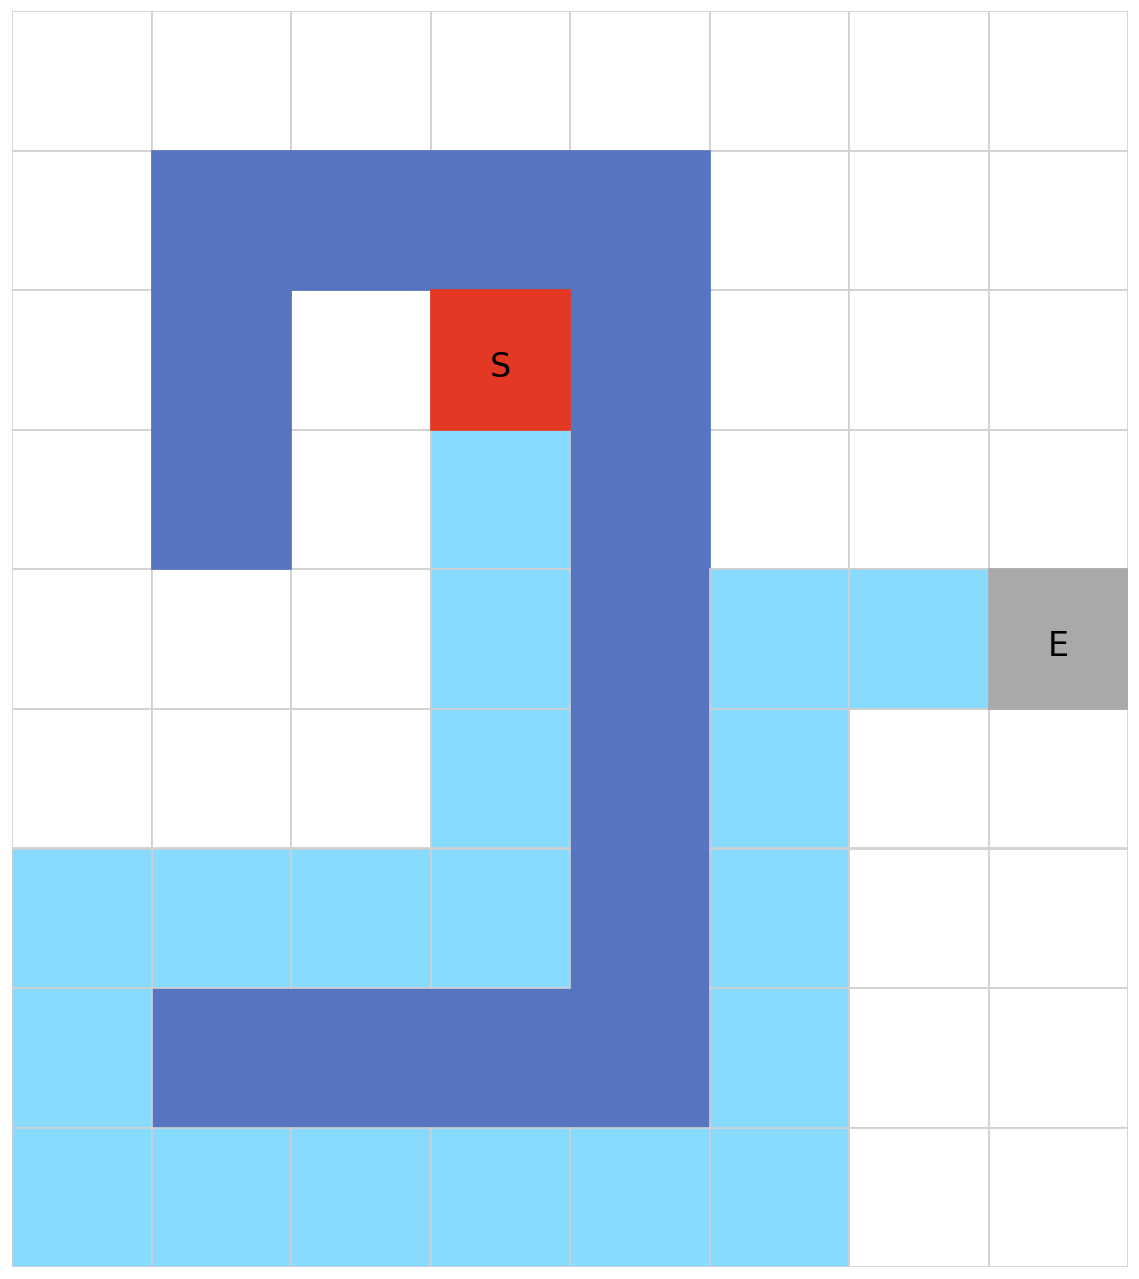

In [35]:
start_time = time.time()
bfs_path, bfs_visited = bfs_search(grid, start, goal)
bfs_time = time.time() - start_time

print("BFS 路径：", bfs_path)
print("BFS 路径长度：", len(bfs_path) - 1 if bfs_path else None)
print("BFS 扩展节点数：", len(bfs_visited))
print("BFS 运行时间：", bfs_time)

draw_grid(
    grid,
    start=start,
    goal=goal,
    path=bfs_path,
)

#### 5. A* 搜索实现

A* 算法是一种启发式搜索算法。与 BFS 不同，A* 不只是盲目地按层扩展，而是通过评价函数选择更有希望到达终点的节点。

A* 的评价函数为：

$$
f(n) = g(n) + h(n)
$$

其中：

- $g(n)$：从起点到当前节点 $n$ 的实际代价；
- $h(n)$：启发函数，从当前节点 $n$ 到终点的估计代价；
- $f(n)$：评价函数，经过当前节点到达终点的总代价估计。

在二维栅格地图中，如果机器人只能上下左右移动，可以使用曼哈顿距离作为启发函数：

$$
h(n) = |x_n - x_g| + |y_n - y_g|
$$

其中 $(x_n, y_n)$ 是当前节点坐标，$(x_g, y_g)$ 是终点坐标。

A* 的基本流程：

1. 将起点加入优先队列；
2. 每次选择 $f(n)$ 最小的节点进行扩展；
3. 更新相邻节点的 $g(n)$、$h(n)$ 和 $f(n)$；
4. 记录每个节点的父节点；
5. 当终点被取出时，恢复路径。

In [25]:
def manhattan_distance(a, b):
    """
    曼哈顿距离：
    适用于只能上下左右移动的网格地图。
    """
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

In [28]:
def astar_search(grid, start, goal):
    """
    使用 A* 算法寻找从 start 到 goal 的最短路径。
    
    返回：
    path: 最终路径
    visited_order: 节点访问顺序
    """
    open_heap = []
    
    # heap 中存储：(f值, g值, 当前节点)
    heapq.heappush(open_heap, (0, 0, start))
    
    parent = {start: None}
    g_score = {start: 0}
    
    visited = set()
    visited_order = []
    
    while open_heap:
        current_f, current_g, current = heapq.heappop(open_heap)
        
        if current in visited:
            continue
        
        visited.add(current)
        visited_order.append(current)
        
        if current == goal:
            path = reconstruct_path(parent, start, goal)
            return path, visited_order
        
        for neighbor in get_neighbors(grid, current):
            tentative_g = g_score[current] + 1
            
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                h = manhattan_distance(neighbor, goal)
                f = tentative_g + h
                
                parent[neighbor] = current
                heapq.heappush(open_heap, (f, tentative_g, neighbor))
    
    return None, visited_order

运行A*并可视化结果：

A* 路径： [(2, 3), (3, 3), (4, 3), (4, 2), (4, 1), (4, 0), (3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (4, 7)]
A* 路径长度： 20
A* 扩展节点数： 57
A* 运行时间： 0.0003197193145751953


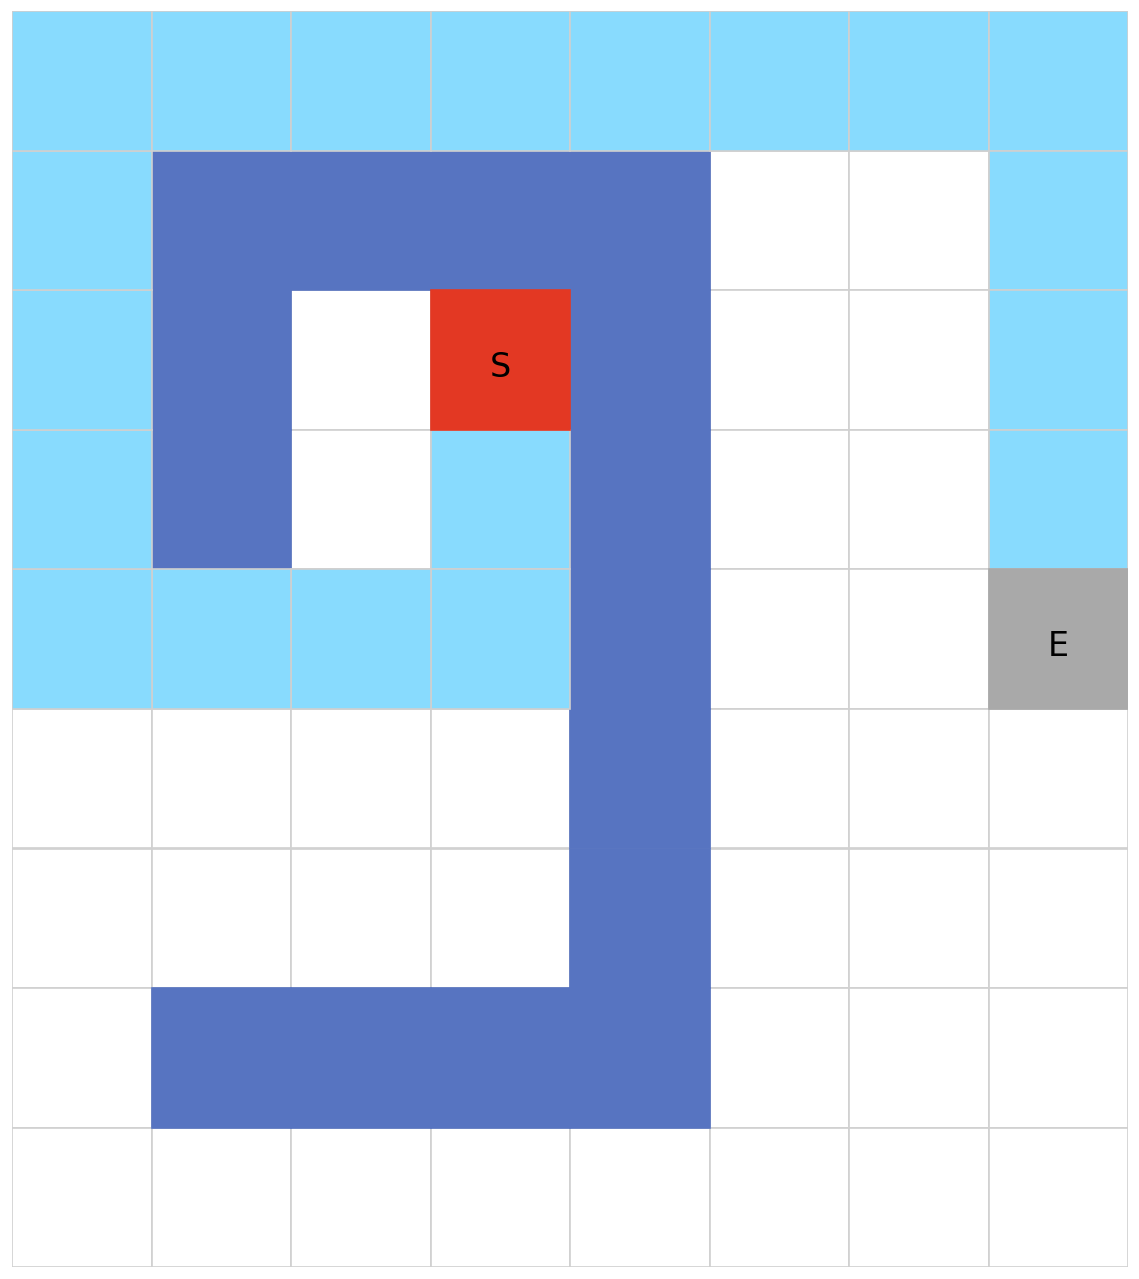

In [36]:
start_time = time.time()
astar_path, astar_visited = astar_search(grid, start, goal)
astar_time = time.time() - start_time

print("A* 路径：", astar_path)
print("A* 路径长度：", len(astar_path) - 1 if astar_path else None)
print("A* 扩展节点数：", len(astar_visited))
print("A* 运行时间：", astar_time)

draw_grid(
    grid,
    start=start,
    goal=goal,
    path=astar_path
)

---
### (2) 在(1)的基础上，比较两种算法的差异、性能区别。

| 指标 | BFS | A* |
|---|---:|---:|
| 路径长度 | 20 | 20 |
| 扩展节点数 | 57 | 57 |
| 运行时间（s） | 0.0002541542053222656 | 0.0003197193145751953 |

结论：
- 在该地图与起终点设置下，BFS 与 A* 得到的**最短路径长度相同**（均为 20）。
- 两者的**扩展节点数相同**（均为 57），说明本次搜索规模一致。
- 本次运行中，BFS 用时略少于 A*（两者数量级接近）。可能原因：
  - 数据结构开销：BFS 主要使用 `deque` 进行队列操作；A* 需要用 `heapq` 维护优先队列($O(\log N)$)，存在额外的堆操作开销。
  - 额外函数调用开销：A* 需要计算启发函数（曼哈顿距离）并计算 `f=g+h`；BFS 不需要这部分计算。

---

### (3) 自主设计更高难度场景图，并结合强化学习、深度强化学习，或使用其他的启发式算法（如遗传算法、人工势场算法）。并进行可能的改进。

#### 1. 使用 PyTorch 实现 DQN 机器人寻径

在前面的实验中，BFS 和 A* 都属于传统搜索算法。它们依赖明确的地图信息和搜索规则，可以直接在地图中搜索从起点到终点的路径。

本部分尝试使用深度强化学习方法 DQN（Deep Q-Network）解决机器人避障寻径问题。DQN 将 Q-learning 与神经网络结合，用神经网络近似动作价值函数：

$$
Q(s, a)
$$

其中：

- $s$ 表示当前状态；
- $a$ 表示动作；
- $Q(s,a)$ 表示在状态 $s$ 下采取动作 $a$ 后，未来能够获得的累计奖励的估计。

在本实验中：

- 状态：机器人当前位置和终点位置；
- 动作：上、下、左、右；
- 奖励：到达终点获得正奖励，撞墙或撞障碍物获得负奖励，普通移动获得小惩罚；
- 目标：通过训练，使机器人学会从起点移动到终点，并尽量避开障碍物。

需要说明的是，DQN 不保证像 BFS 或 A* 一样一定找到最短路径。本部分主要用于展示深度强化学习求解路径规划问题的基本思想。

In [64]:
import random

import torch
import torch.nn as nn
import torch.optim as optim

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

设计地图：

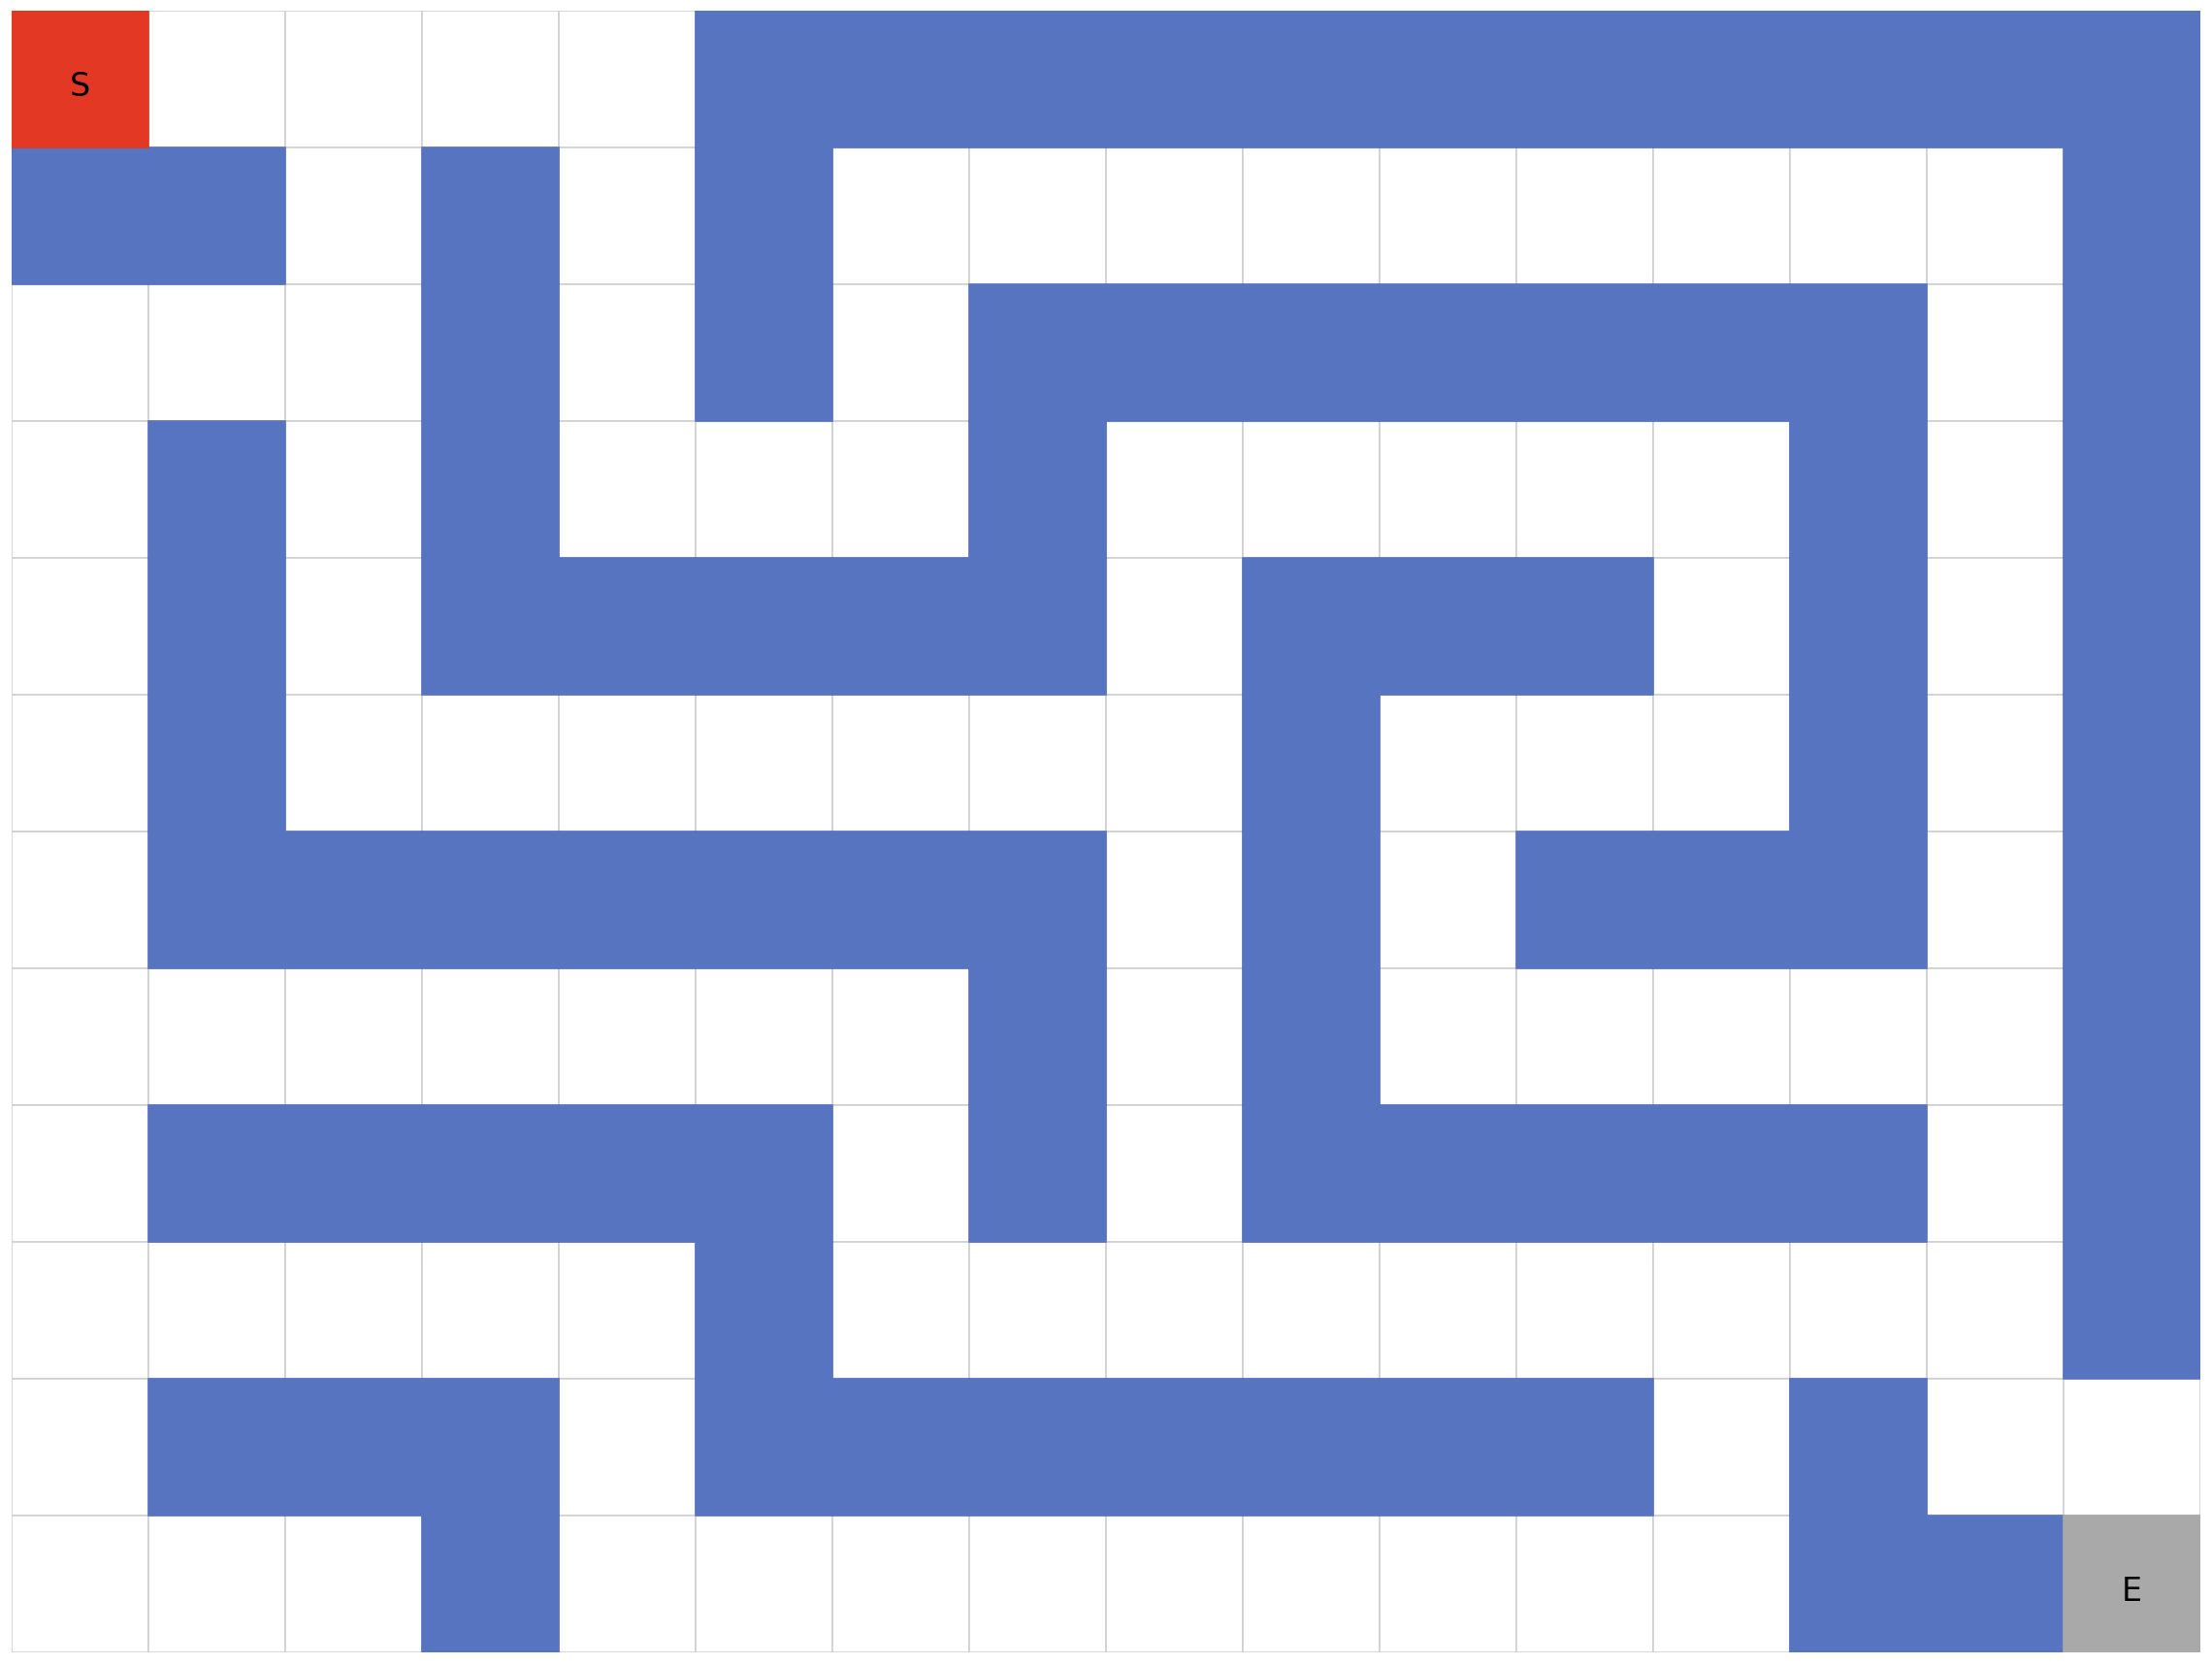

In [10]:
rl_grid = np.array([
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1],
    [0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0],
], dtype=int)

rl_start = (0, 0)
rl_goal = (11, 15)

draw_grid(
    rl_grid,
    start=rl_start,
    goal=rl_goal,
)

#### 2. 强化学习环境设计

强化学习通常需要定义一个环境。智能体在环境中执行动作，环境返回新的状态、奖励以及是否结束。

本实验中的环境设计如下：

- 状态

使用 4 个数表示：

$$
(row, col, goal\_row, goal\_col)
$$

为了方便神经网络训练，将坐标归一化到 $[0,1]$。

- 动作

动作空间共有 4 个动作：

| 动作编号 | 含义 |
|---|---|
| 0 | 上 |
| 1 | 下 |
| 2 | 左 |
| 3 | 右 |

- 奖励

奖励函数设计如下：

- 到达终点：+20
- 撞墙或撞到障碍物：-10
- 普通移动：-0.1
- 如果向终点靠近：额外 +0.05
- 如果远离终点：额外 -0.05

额外奖励称为 reward shaping，可以帮助智能体更快学习。

In [67]:
class GridWorldEnv:
    def __init__(self, grid, start, goal, max_steps=None):
        self.grid = grid
        self.start = start
        self.goal = goal
        
        self.rows, self.cols = grid.shape
        self.actions = [
            (-1, 0),  # 上
            (1, 0),   # 下
            (0, -1),  # 左
            (0, 1),   # 右
        ]
        
        self.max_steps = max_steps if max_steps is not None else self.rows * self.cols * 4
        
        self.agent_pos = None
        self.steps = 0
    
    def reset(self):
        self.agent_pos = self.start
        self.steps = 0
        return self._get_state()
    
    def _get_state(self):
        """
        状态归一化：
        [当前行, 当前列, 目标行, 目标列]
        """
        r, c = self.agent_pos
        gr, gc = self.goal
        
        return np.array([
            r / (self.rows - 1),
            c / (self.cols - 1),
            gr / (self.rows - 1),
            gc / (self.cols - 1),
        ], dtype=np.float32)
    
    def _is_valid(self, pos):
        r, c = pos
        
        if r < 0 or r >= self.rows or c < 0 or c >= self.cols:
            return False
        
        if self.grid[r, c] == 1:
            return False
        
        return True
    
    def _manhattan_to_goal(self, pos):
        return abs(pos[0] - self.goal[0]) + abs(pos[1] - self.goal[1])
    
    def step(self, action):
        old_pos = self.agent_pos
        old_dist = self._manhattan_to_goal(old_pos)
        
        dr, dc = self.actions[action]
        new_pos = (old_pos[0] + dr, old_pos[1] + dc)
        
        self.steps += 1
        
        # 撞墙或撞障碍物
        if not self._is_valid(new_pos):
            reward = -5.0
            done = False
            info = {"result": "collision"}
            return self._get_state(), reward, done, info
        
        self.agent_pos = new_pos
        new_dist = self._manhattan_to_goal(new_pos)
        
        # 到达终点
        if new_pos == self.goal:
            reward = 40.0
            done = True
            info = {"result": "goal"}
            return self._get_state(), reward, done, info
        
        # 普通移动惩罚
        reward = -0.1
        
        # 奖励靠近终点，惩罚远离终点
        if new_dist < old_dist:
            reward += 0.3
        elif new_dist > old_dist:
            reward -= 0.3
        
        # 超过最大步数
        if self.steps >= self.max_steps:
            done = True
            info = {"result": "timeout"}
        else:
            done = False
            info = {"result": "moving"}
        
        return self._get_state(), reward, done, info

#### 3. DQN 网络结构

DQN 使用神经网络近似动作价值函数 $Q(s,a)$。

本实验中，网络输入为状态向量：

$$
[row, col, goal\_row, goal\_col]
$$

输出为 4 个动作的 Q 值：

$$
[Q_{up}, Q_{down}, Q_{left}, Q_{right}]
$$

智能体在选择动作时，会选择 Q 值最大的动作。

In [68]:
class QNetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=4):
        super(QNetwork, self).__init__()
        
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
    
    def forward(self, x):
        return self.net(x)

#### 4. 经验回放

DQN 通常使用经验回放机制。智能体每次与环境交互后，会存储一条经验：

$$
(s, a, r, s', done)
$$

训练时，随机抽取一批经验来更新神经网络。

这样可以打乱样本之间的相关性，使训练更加稳定。

In [69]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).to(device)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

#### 5. DQN 更新公式

DQN 的训练目标来自 Q-learning 的贝尔曼方程。

对于一条经验 $(s, a, r, s')$，目标 Q 值为：

$$
y = r + \gamma \max_{a'} Q_{target}(s', a')
$$

如果 $s'$ 是终止状态，则：

$$
y = r
$$

训练时，神经网络当前预测值为：

$$
Q(s,a)
$$

损失函数采用均方误差：

$$
Loss = (Q(s,a) - y)^2
$$

其中：

- $\gamma$ 是折扣因子；
- $Q_{target}$ 是目标网络，用于提高训练稳定性。

#### 6. 训练 DQN

In [70]:
# 固定随机种子，方便复现实验
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

env = GridWorldEnv(rl_grid, rl_start, rl_goal)

state_dim = 4
action_dim = 4

policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)

# 初始时目标网络参数与策略网络一致
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

replay_buffer = ReplayBuffer(capacity=10000)

gamma = 0.95
batch_size = 64
num_episodes = 800
target_update_interval = 20

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.998

episode_rewards = []
episode_success = []
loss_history = []

In [71]:
for episode in range(num_episodes):
    state = env.reset()
    total_reward = 0
    success = False
    
    for step in range(env.max_steps):
        # epsilon-贪心策略：以 epsilon 概率随机探索，否则选择当前认为最优的动作
        if random.random() < epsilon:
            action = random.randint(0, action_dim - 1)
        else:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                q_values = policy_net(state_tensor)
                action = q_values.argmax(dim=1).item()
        
        next_state, reward, done, info = env.step(action)
        
        replay_buffer.push(state, action, reward, next_state, done)
        
        state = next_state
        total_reward += reward
        
        if info["result"] == "goal":
            success = True
        
        # 当经验池中的数据足够时，开始训练
        if len(replay_buffer) >= batch_size:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)
            
            # 当前网络预测 Q(s,a)
            current_q = policy_net(states).gather(1, actions).squeeze(1)
            
            # 目标网络计算 max Q(s', a')
            with torch.no_grad():
                next_q = target_net(next_states).max(dim=1)[0]
                target_q = rewards + gamma * next_q * (1 - dones)
            
            loss = loss_fn(current_q, target_q)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_history.append(loss.item())
        
        if done:
            break
    
    episode_rewards.append(total_reward)
    episode_success.append(1 if success else 0)
    
    # 更新目标网络
    if (episode + 1) % target_update_interval == 0:
        target_net.load_state_dict(policy_net.state_dict())
    
    # 衰减 epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    if (episode + 1) % 100 == 0:
        recent_success_rate = np.mean(episode_success[-100:])
        recent_reward = np.mean(episode_rewards[-100:])
        
        print(
            f"Episode {episode + 1:4d} | "
            f"epsilon={epsilon:.3f} | "
            f"avg_reward={recent_reward:.2f} | "
            f"success_rate={recent_success_rate:.2f}"
        )

Episode  100 | epsilon=0.819 | avg_reward=-1298.87 | success_rate=0.57
Episode  200 | epsilon=0.670 | avg_reward=-899.01 | success_rate=0.65
Episode  300 | epsilon=0.548 | avg_reward=-677.27 | success_rate=0.61
Episode  400 | epsilon=0.449 | avg_reward=-139.21 | success_rate=0.96
Episode  500 | epsilon=0.368 | avg_reward=-148.12 | success_rate=0.97
Episode  600 | epsilon=0.301 | avg_reward=-65.39 | success_rate=1.00
Episode  700 | epsilon=0.246 | avg_reward=20.03 | success_rate=1.00
Episode  800 | epsilon=0.202 | avg_reward=27.19 | success_rate=1.00


可视化：

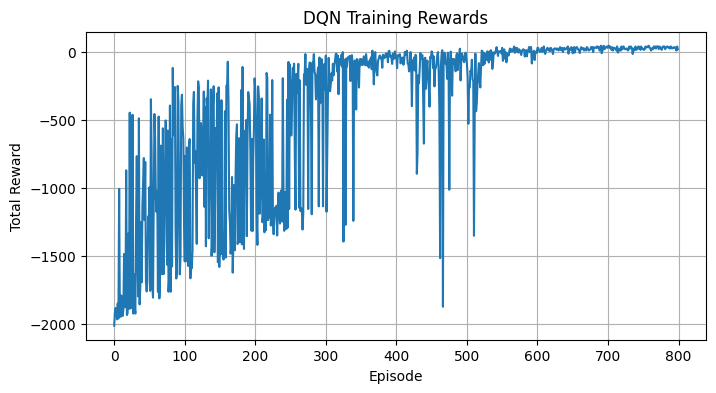

In [72]:
plt.figure(figsize=(8, 4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Training Rewards")
plt.grid(True)
plt.show()

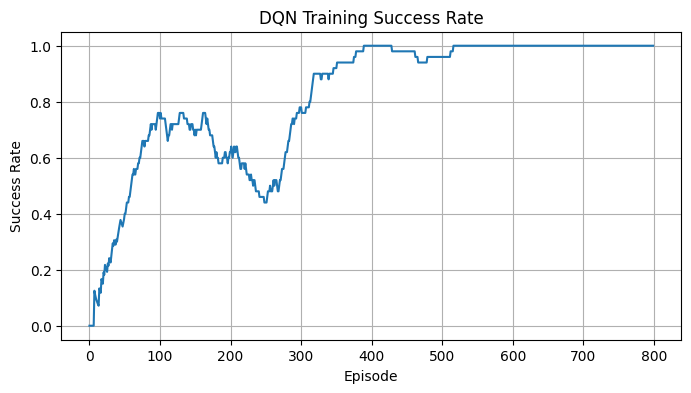

In [73]:
window = 50
success_rate = []

for i in range(len(episode_success)):
    start_idx = max(0, i - window + 1)
    success_rate.append(np.mean(episode_success[start_idx:i+1]))

plt.figure(figsize=(8, 4))
plt.plot(success_rate)
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.title("DQN Training Success Rate")
plt.grid(True)
plt.show()

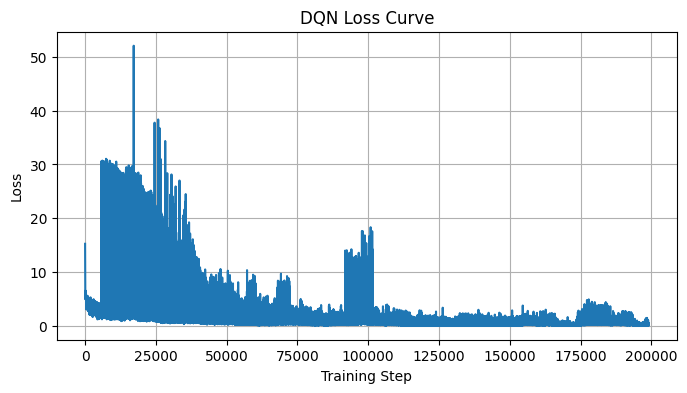

In [74]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("DQN Loss Curve")
plt.grid(True)
plt.show()

#### 7. 使用训练好的模型生成路径

In [75]:
def generate_dqn_path(env, policy_net, max_steps=None):
    """
    使用训练好的 DQN 网络，采用贪心策略生成路径。
    """
    state = env.reset()
    path = [env.agent_pos]
    
    if max_steps is None:
        max_steps = env.max_steps
    
    for _ in range(max_steps):
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = policy_net(state_tensor)
            action = q_values.argmax(dim=1).item()
        
        next_state, reward, done, info = env.step(action)
        path.append(env.agent_pos)
        state = next_state
        
        if done:
            return path, info
    
    return path, {"result": "max_steps"}

DQN 结果： {'result': 'goal'}
DQN 路径： [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (4, 2), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (6, 8), (7, 8), (8, 8), (9, 8), (9, 9), (9, 10), (9, 11), (9, 12), (9, 13), (9, 14), (10, 14), (10, 15), (11, 15)]
DQN 路径长度： 26


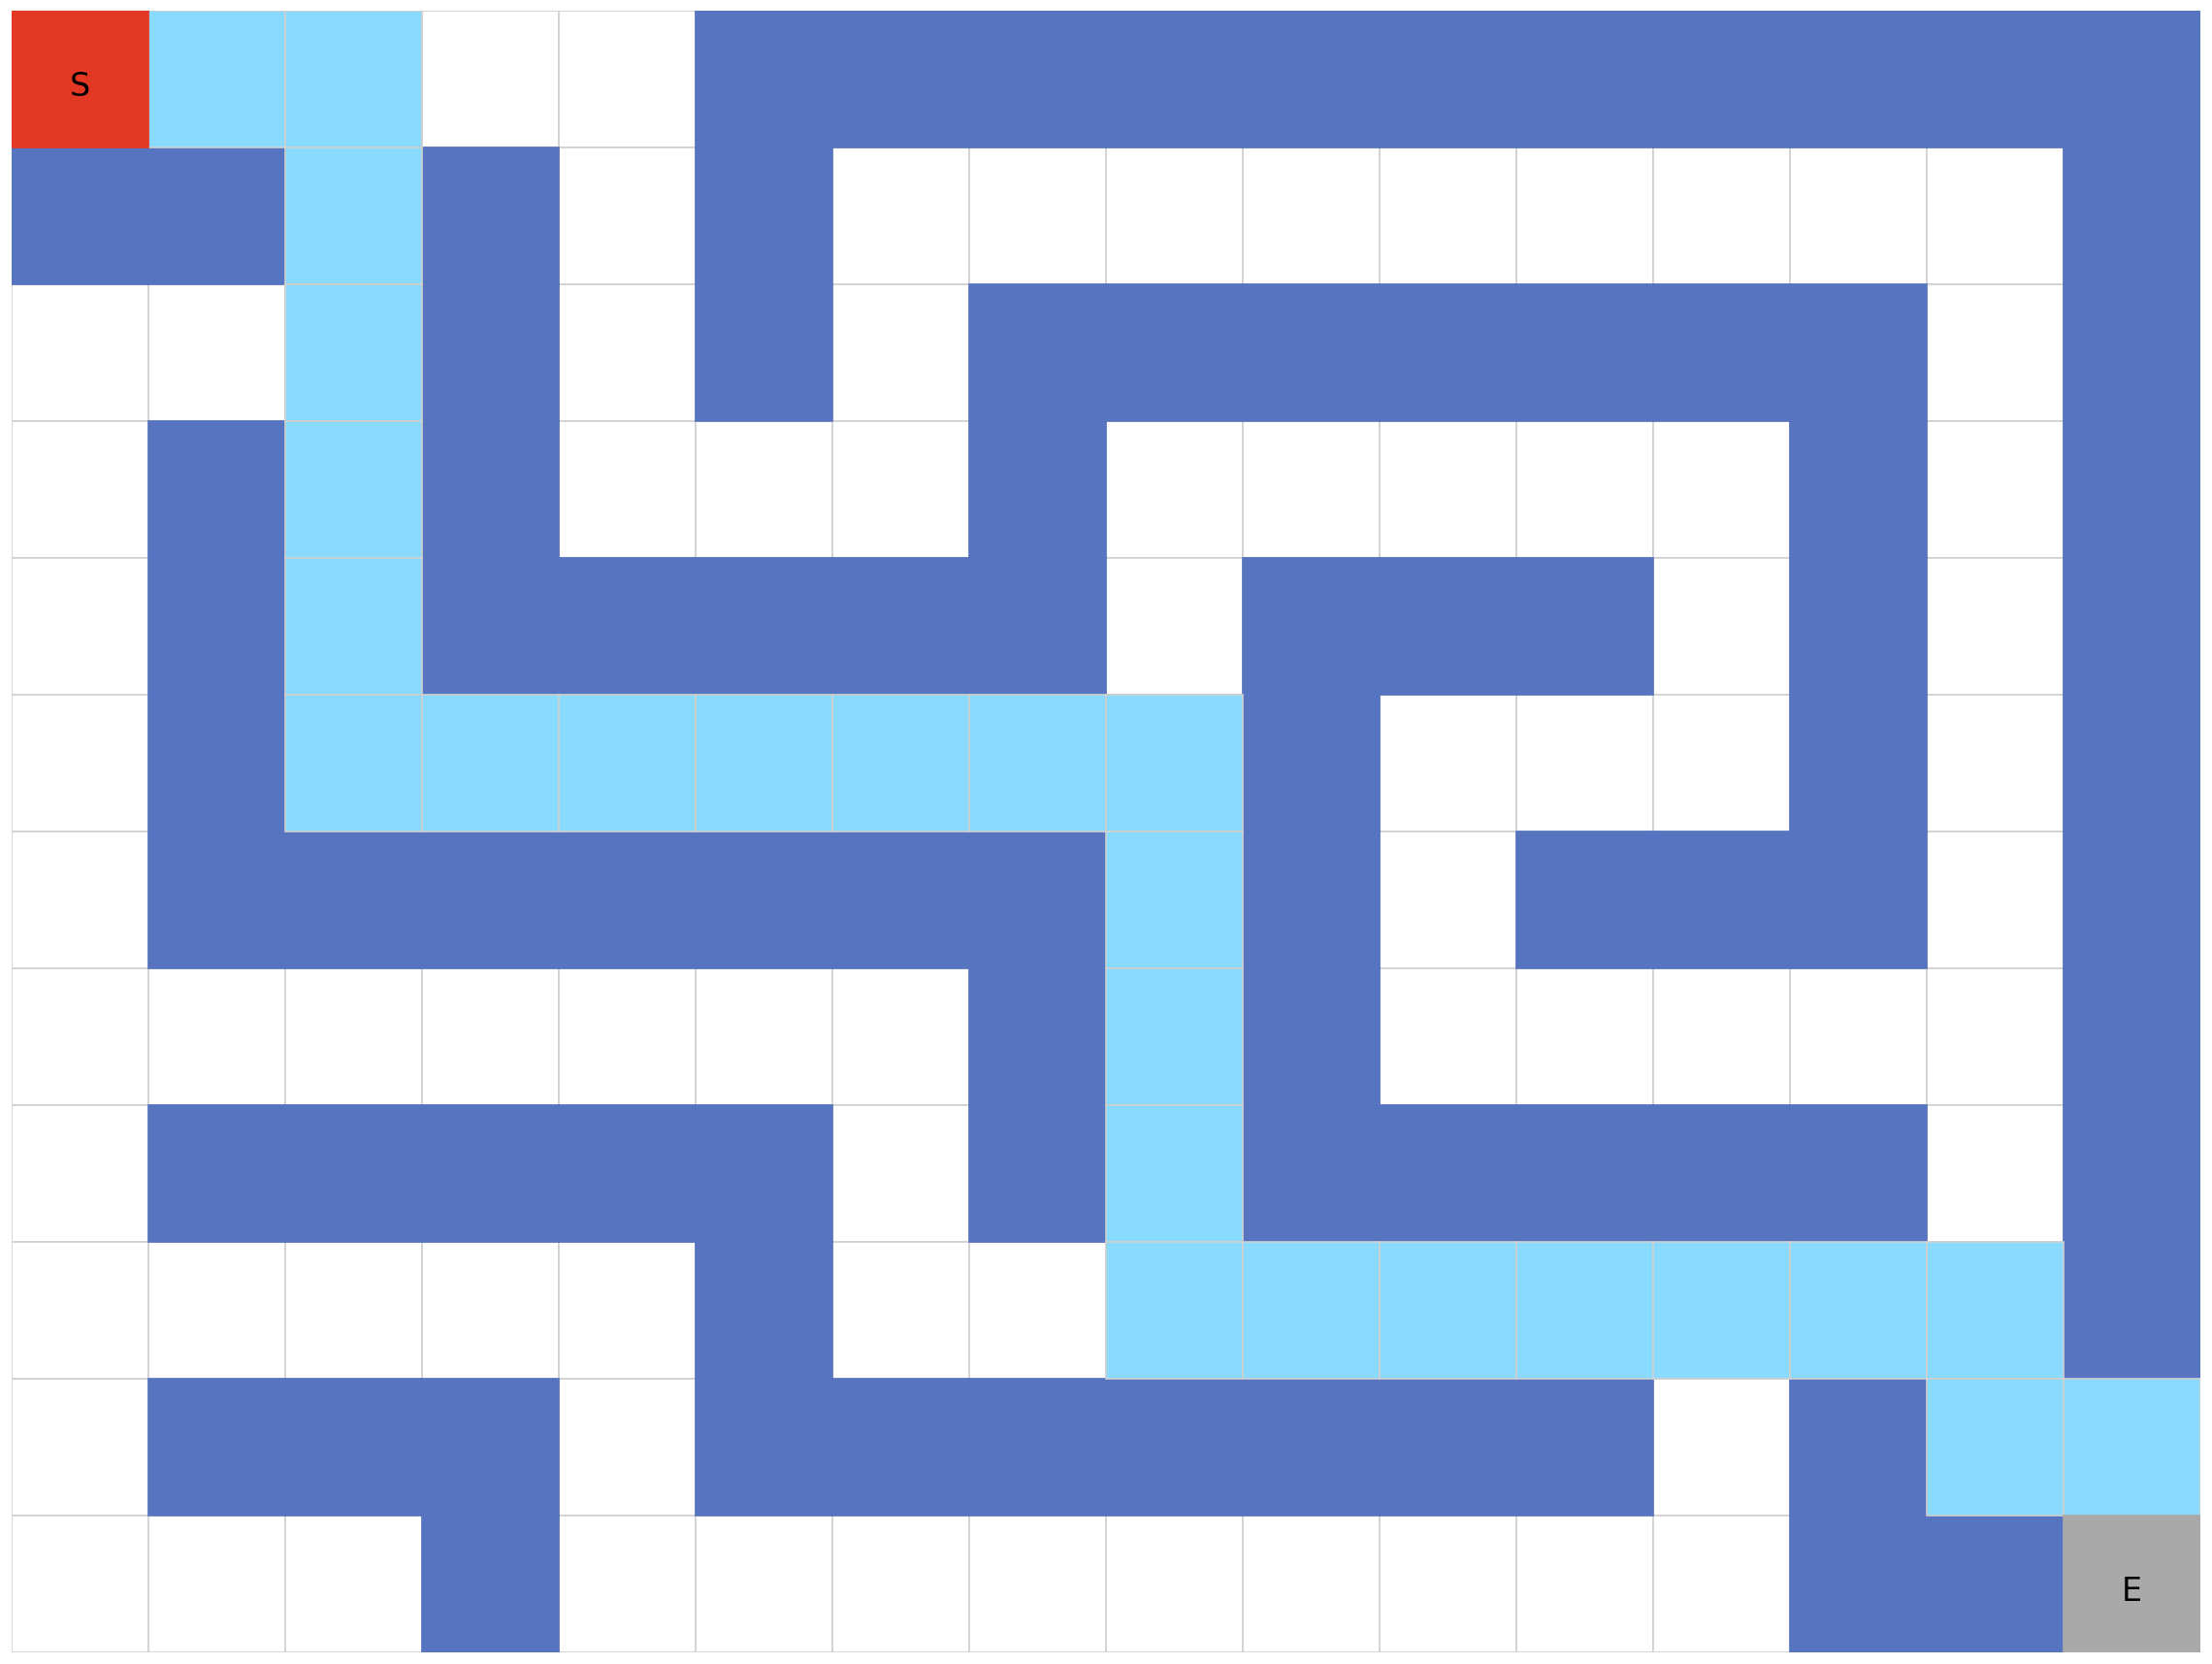

In [76]:
test_env = GridWorldEnv(rl_grid, rl_start, rl_goal)
dqn_path, dqn_info = generate_dqn_path(test_env, policy_net)

print("DQN 结果：", dqn_info)
print("DQN 路径：", dqn_path)
print("DQN 路径长度：", len(dqn_path) - 1)

draw_grid(
    rl_grid,
    start=rl_start,
    goal=rl_goal,
    path=dqn_path,
)

#### 8.实验总结

- 训练设置：共训练 `800` 个 episode，最终探索率 `epsilon=0.202`。
- 训练效果（统计最后 100 个 episode）：`avg_reward=27.19 | success_rate=1.00`。
- 测试生成路径结果：`dqn_info={'result': 'goal'}`，说明成功到达终点；生成路径长度为 `26` 步，且路径终点 `(11, 15)` 与目标点 `(11, 15)` 一致。

#### 9.可能的改进方向

- 调整奖励函数与 `reward shaping`：分别测试不同的到达奖励/碰撞惩罚/步惩罚系数，并记录最后 50 episode 的 `avg_reward`、`success_rate` 以及测试路径长度，用于判断是否更稳定或更短。
- 调整 DQN 训练超参数：如 `epsilon` 衰减策略、学习率、目标网络更新频率、replay buffer 与 batch size 等；同样以“最后 50 episode 的统计值 + 测试路径长度/是否到达 goal”作为对比基准。
- 多随机种子重复实验：改变随机种子重复训练多次，统计均值与方差，避免单次结果偶然偏好导致结论不稳。

---

### (4) 提出其他不同的解决方案（如Dijkstra等）。分析所设计算法的局限性，及改进点。

除了 BFS 和 A* 算法之外，Dijkstra 算法也是经典的最短路径搜索算法。

Dijkstra 算法适用于边权非负的图，可以从起点出发，逐步确定从起点到其他节点的最短距离。在栅格地图中，如果每次移动的代价相同，则 Dijkstra 算法也可以找到从起点到终点的最短路径。

与 BFS 不同的是，BFS 默认每一步代价相同，而 Dijkstra 可以处理不同移动代价的情况。与 A* 不同的是，Dijkstra 不使用启发函数，因此搜索方向不如 A* 明确。

#### 1. Dijkstra 算法原理

Dijkstra 算法的核心思想是：

1. 从起点开始，将起点距离设为 0；
2. 使用优先队列维护当前可扩展节点；
3. 每次取出当前距离起点最近的节点；
4. 用该节点更新其相邻节点的距离；
5. 如果找到更短路径，则更新距离并记录父节点；
6. 当终点被取出时，说明已经找到从起点到终点的最短路径。

Dijkstra 算法的评价依据是：

$$
f(n) = g(n)
$$

其中：

- $g(n)$ 表示从起点到当前节点 $n$ 的实际路径代价。

而 A* 算法的评价函数是：

$$
f(n) = g(n) + h(n)
$$

因此，可以将 Dijkstra 理解为没有启发函数的 A*。

In [14]:
def dijkstra_search(grid, start, goal):
    """
    使用 Dijkstra 算法寻找从 start 到 goal 的最短路径。
    
    参数：
    grid: 二维栅格地图，0 表示可通行，1 表示障碍物
    start: 起点坐标，例如 (row, col)
    goal: 终点坐标，例如 (row, col)
    
    返回：
    path: 最短路径
    visited_order: 节点扩展顺序
    distance: 从起点到各节点的最短距离字典
    """
    open_heap = []
    heapq.heappush(open_heap, (0, start))
    
    distance = {start: 0}
    parent = {start: None}
    
    visited = set()
    visited_order = []
    
    while open_heap:
        current_dist, current = heapq.heappop(open_heap)
        
        if current in visited:
            continue
        
        visited.add(current)
        visited_order.append(current)
        
        if current == goal:
            path = reconstruct_path(parent, start, goal)
            return path, visited_order, distance
        
        for neighbor in get_neighbors(grid, current):
            # 本实验中每移动一步代价为 1
            step_cost = 1
            new_dist = current_dist + step_cost
            
            if neighbor not in distance or new_dist < distance[neighbor]:
                distance[neighbor] = new_dist
                parent[neighbor] = current
                heapq.heappush(open_heap, (new_dist, neighbor))
    
    return None, visited_order, distance

运行

In [15]:
start_time = time.time()

dijkstra_path, dijkstra_visited, dijkstra_distance = dijkstra_search(
    rl_grid, #这里使用复杂的地图
    rl_start,
    rl_goal
)

dijkstra_time = time.time() - start_time

print("Dijkstra 是否找到路径：", dijkstra_path is not None)
print("Dijkstra 路径：", dijkstra_path)
print("Dijkstra 路径长度：", len(dijkstra_path) - 1 if dijkstra_path else None)
print("Dijkstra 扩展节点数：", len(dijkstra_visited))
print("Dijkstra 运行时间：", dijkstra_time)

Dijkstra 是否找到路径： True
Dijkstra 路径： [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (3, 2), (4, 2), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (6, 8), (7, 8), (8, 8), (9, 8), (9, 9), (9, 10), (9, 11), (9, 12), (9, 13), (9, 14), (10, 14), (10, 15), (11, 15)]
Dijkstra 路径长度： 26
Dijkstra 扩展节点数： 102
Dijkstra 运行时间： 0.0007479190826416016


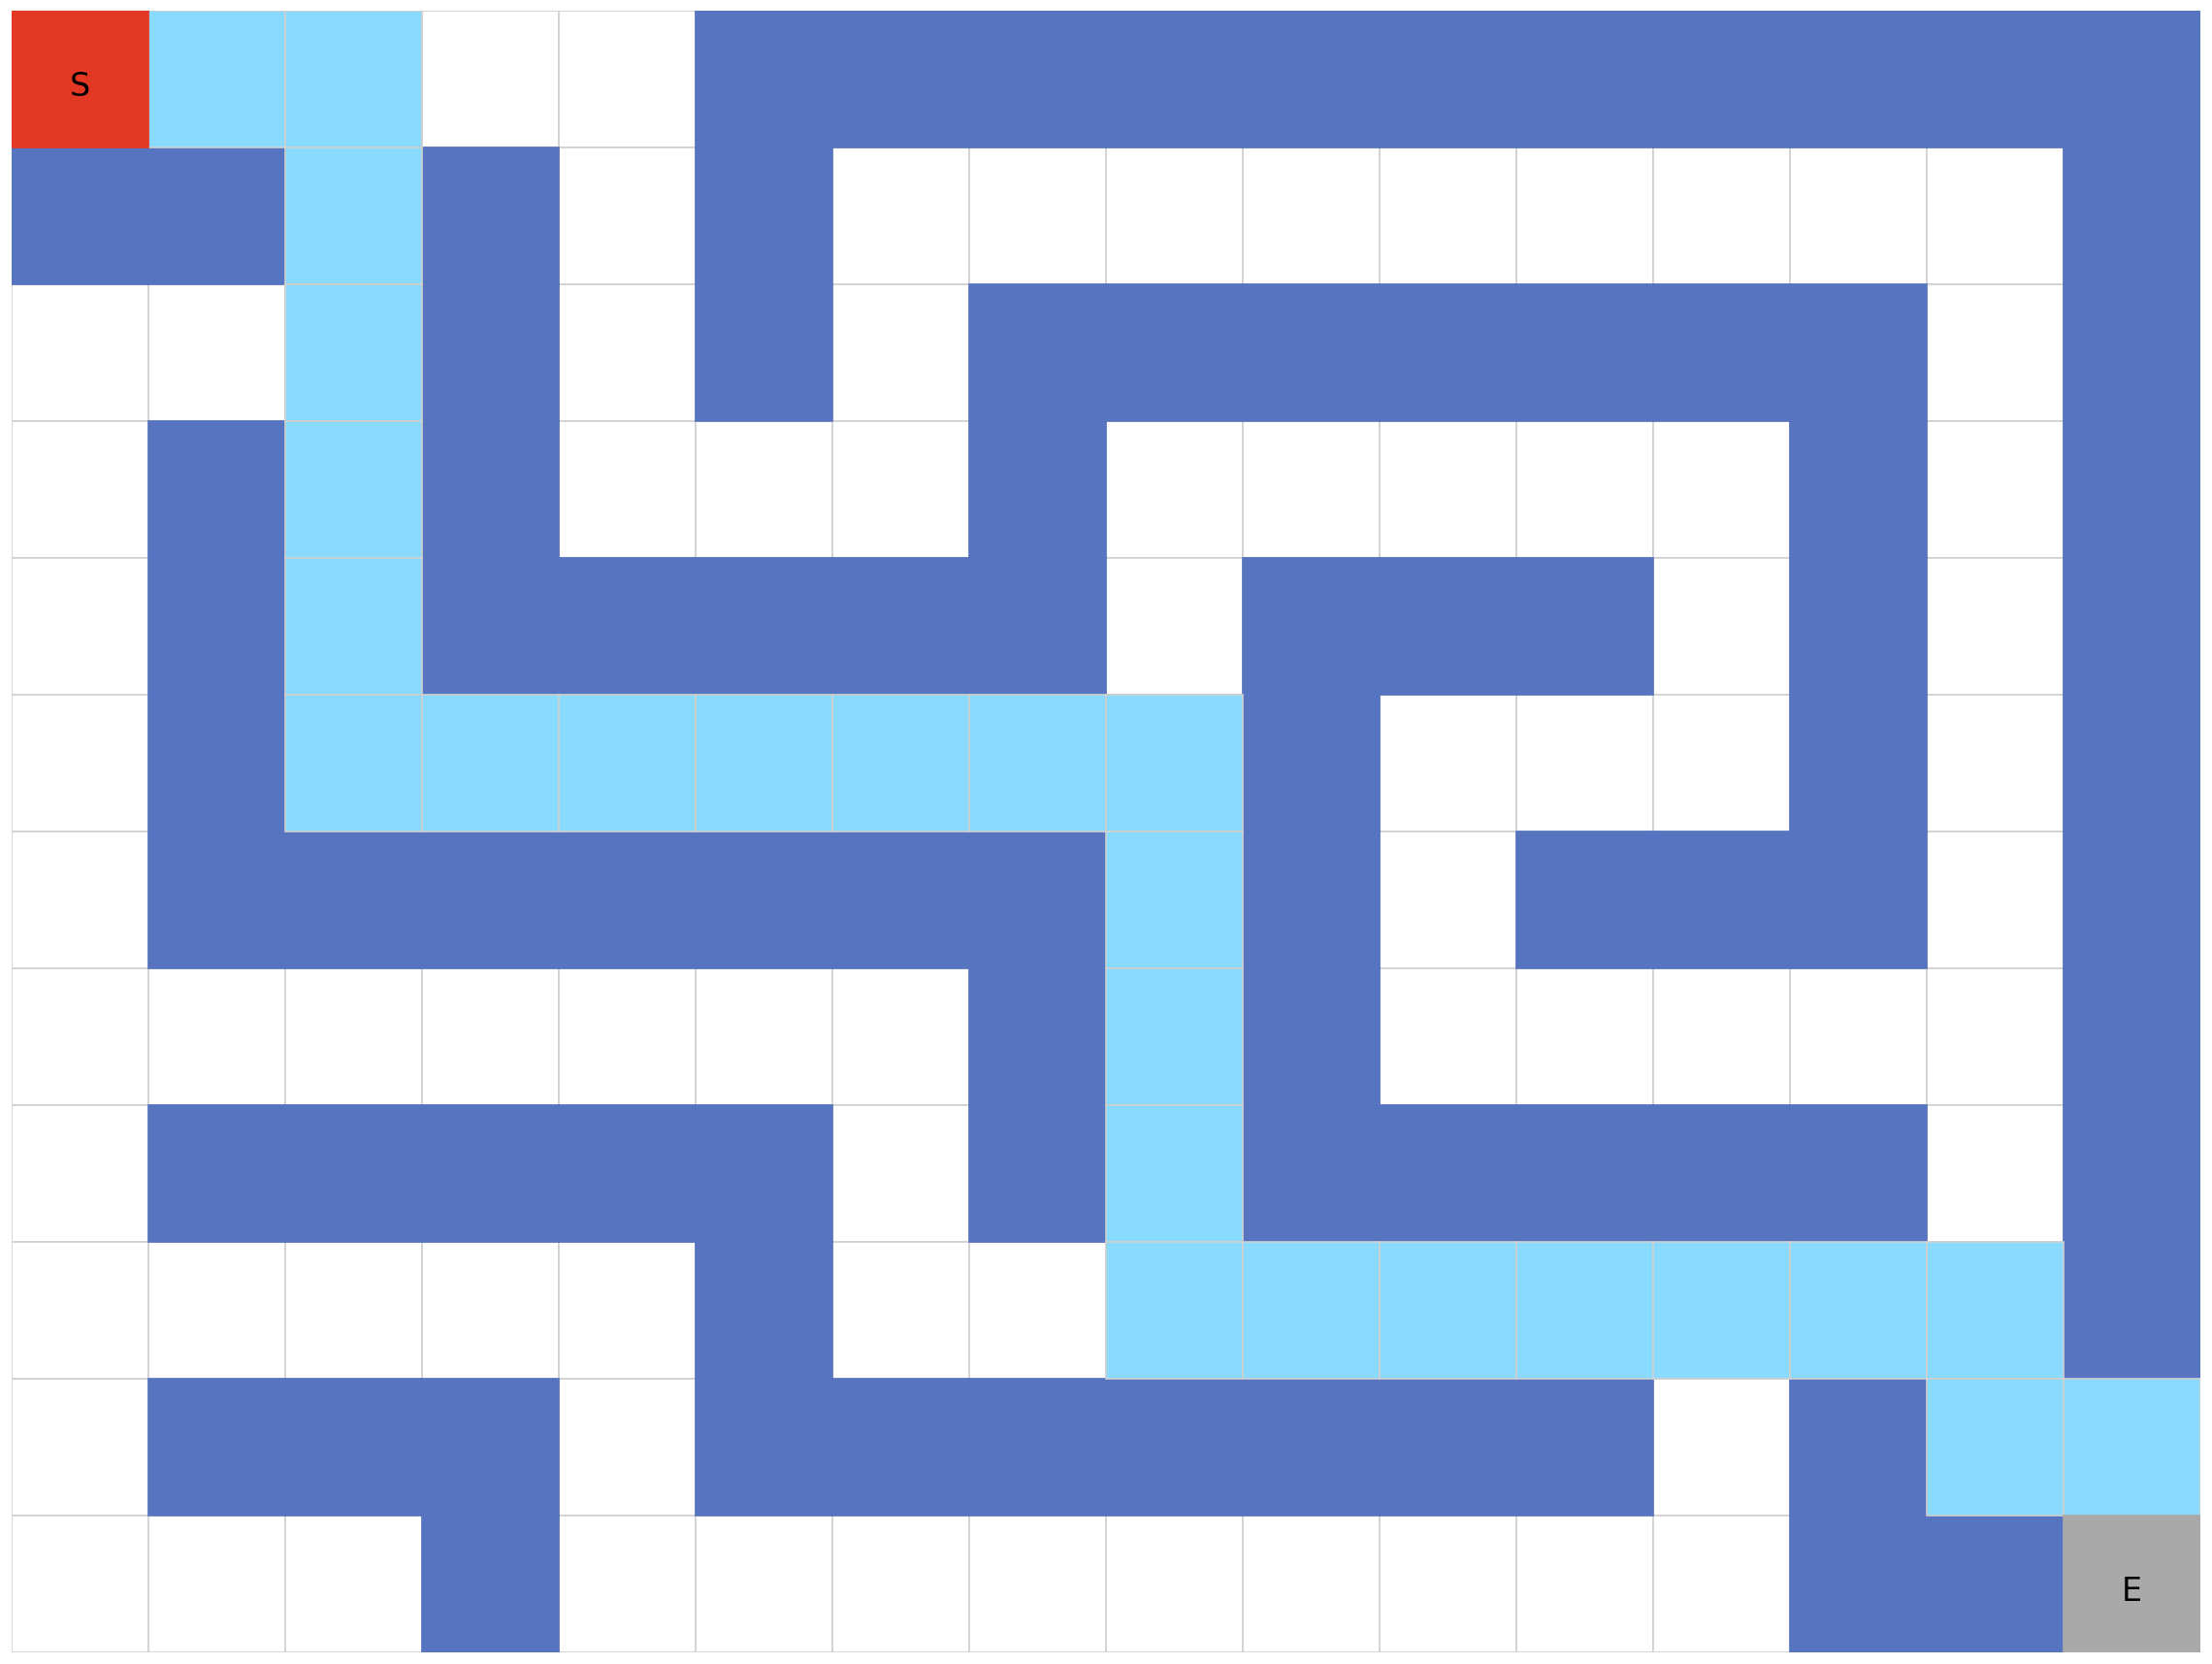

In [17]:
draw_grid(
    rl_grid,
    start=rl_start,
    goal=rl_goal,
    path=dijkstra_path,
)

#### 2. Dijkstra 算法的局限性

Dijkstra 算法能够在边权非负的图中找到最短路径，但在本实验的栅格地图中仍存在一定局限。

首先，Dijkstra 只根据从起点到当前节点的实际代价 $g(n)$ 选择扩展节点，不使用目标方向的启发信息。因此它的搜索过程缺乏方向性，容易向起点周围均匀扩展，可能访问较多与终点无关的节点。

其次，本实验中每一步移动代价均为 $1$，属于等权图。在这种情况下，Dijkstra 与 BFS 得到的路径长度通常相同，但 Dijkstra 需要维护优先队列，实现和运行开销相对更高，因此优势并不明显。

最后，Dijkstra 默认地图信息已知且障碍物静态。如果环境中出现动态障碍物，原先规划好的路径可能失效，需要重新搜索。

#### 3. Dijkstra 算法的改进点

针对上述问题，可以从以下几个方面改进 Dijkstra 算法。

第一，引入启发函数，将 Dijkstra 改进为 A* 算法。Dijkstra 的评价依据是：

$$
f(n)=g(n)
$$

而 A* 的评价函数为：

$$
f(n)=g(n)+h(n)
$$

其中 $h(n)$ 表示当前节点到目标节点的估计代价。加入启发函数后，搜索会更倾向于终点方向，从而减少无关节点扩展。

第二，可以为不同格子设置不同通行代价。例如，靠近障碍物的格子代价更高，宽阔区域代价较低。这样 Dijkstra 不仅能寻找最短路径，也能倾向于选择更安全的路径。

第三，对于动态障碍物场景，可以在障碍物变化后重新规划路径，或进一步使用 D*、D* Lite 等适合动态环境的路径规划算法。

---
### (5) 最短路径查找过程的动态化展示

In [20]:
def animate_search(grid, start, goal, visited_order, path=None, delay=0.1):
    """
    动态展示搜索过程：
    - 搜索过程中显示 visited 的扩展
    - 最终到达终点后，仅保留 path（擦除 path 之外 visited 的着色）
    """
    visited_so_far = []
    
    for node in visited_order:
        visited_so_far.append(node)
        clear_output(wait=True)
        draw_grid(
            grid,
            start=start,
            goal=goal,
            visited=visited_so_far,
        )
        time.sleep(delay)
    
    if path is not None:
        clear_output(wait=True)
        draw_grid(
            grid,
            start=start,
            goal=goal,
            path=path,
        )

BFS搜索过程可视化：

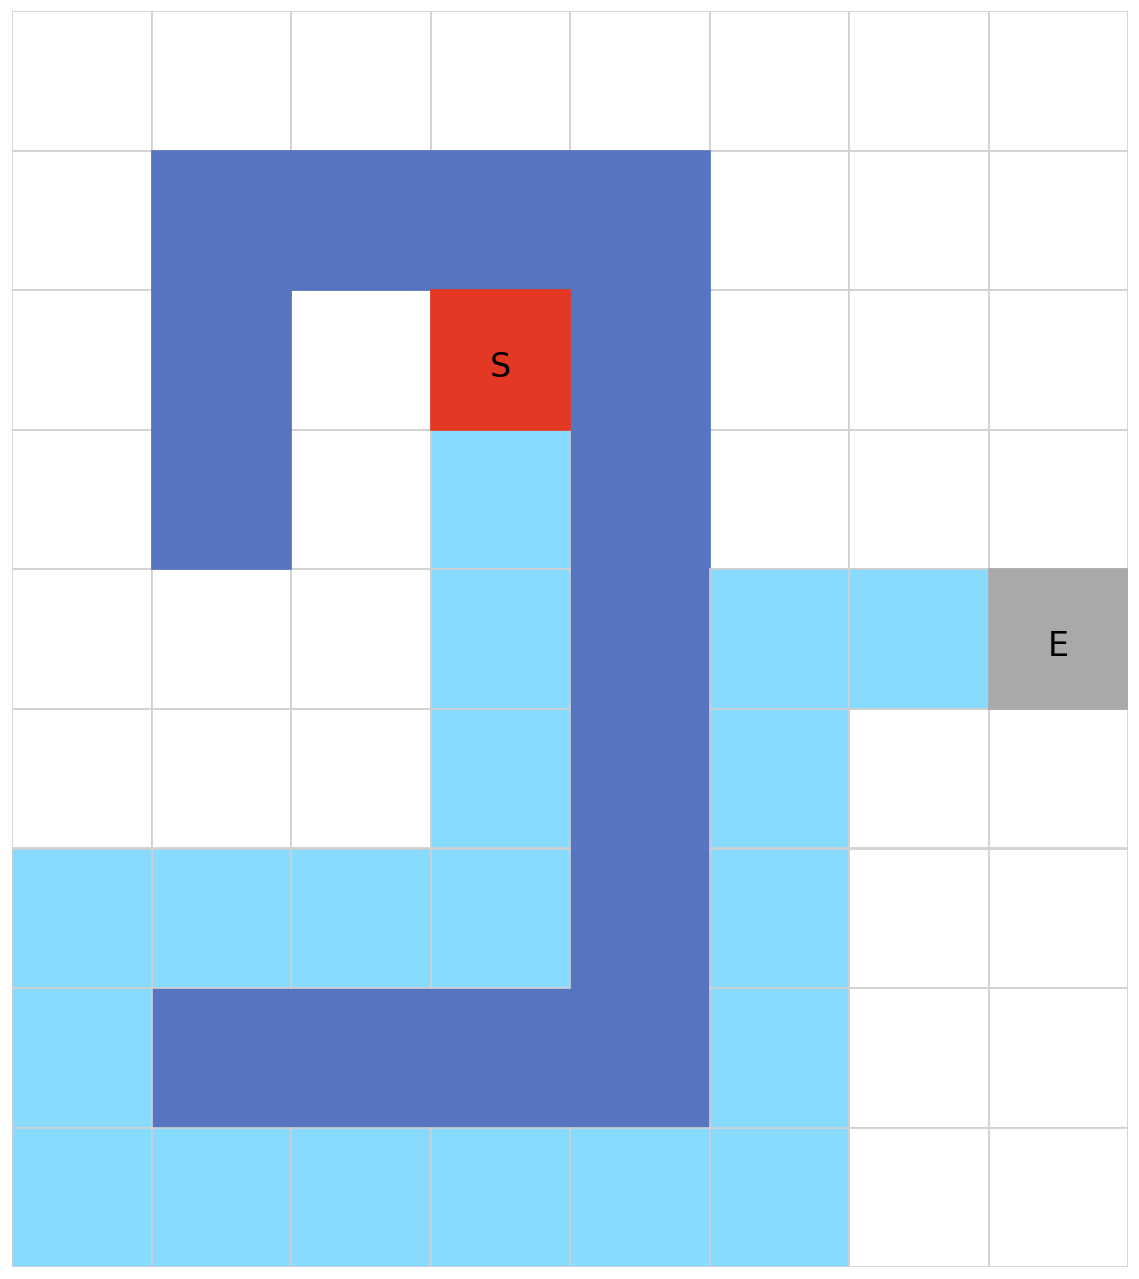

In [33]:
animate_search(
    grid,
    start,
    goal,
    bfs_visited,
    bfs_path,
    delay=0.15
)

A*搜索过程可视化

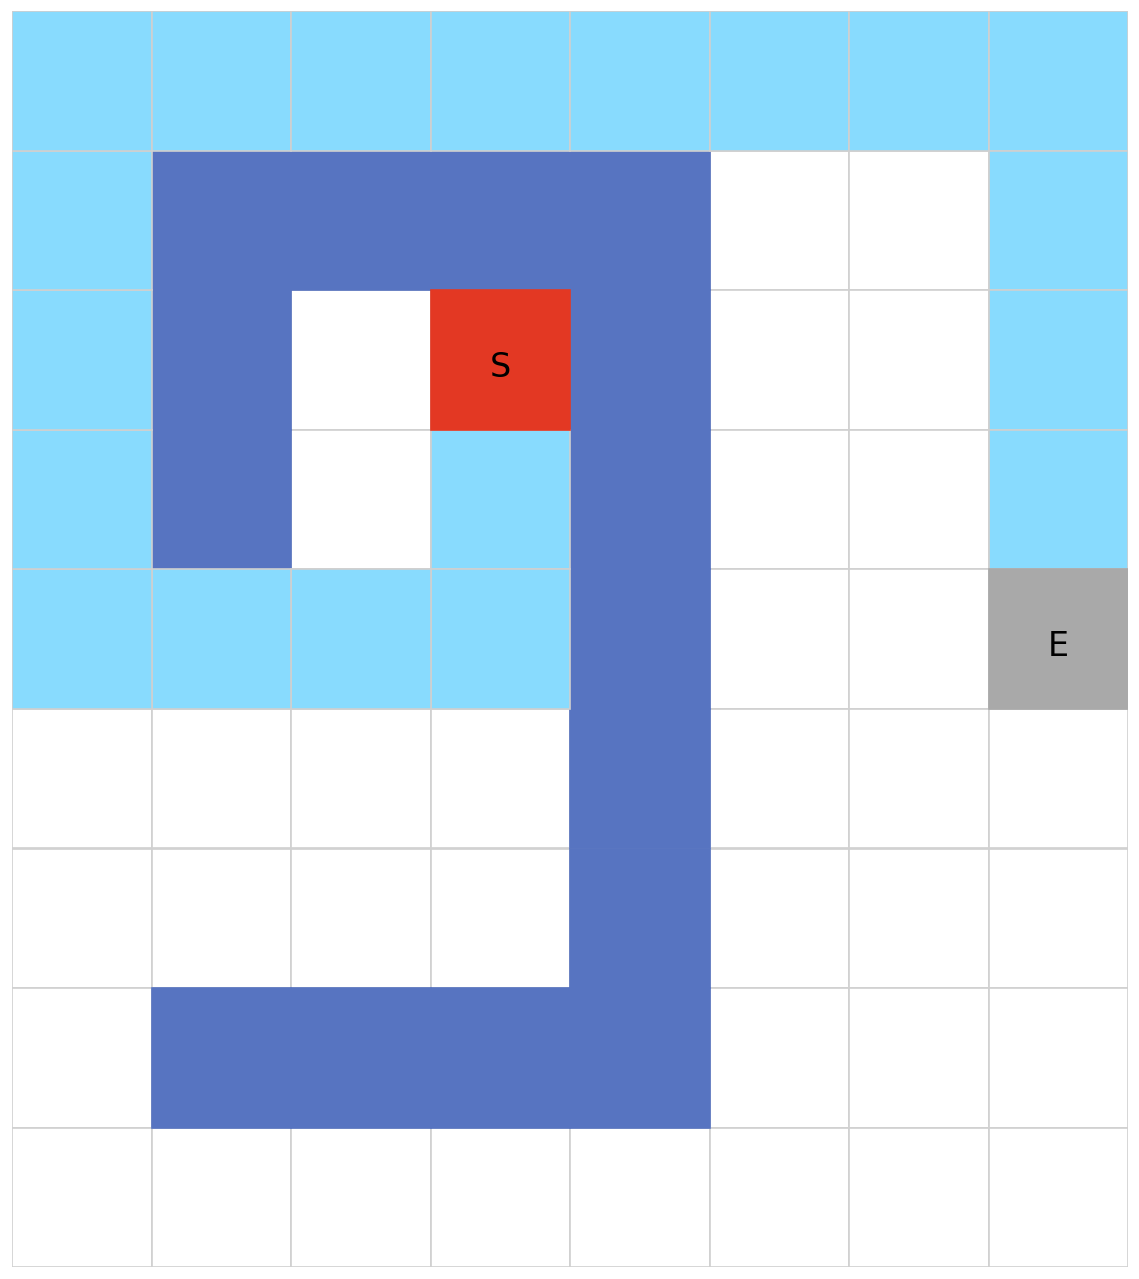

In [34]:
animate_search(
    grid,
    start,
    goal,
    astar_visited,
    astar_path,
    delay=0.15
)

DQN 路径过程可视化：

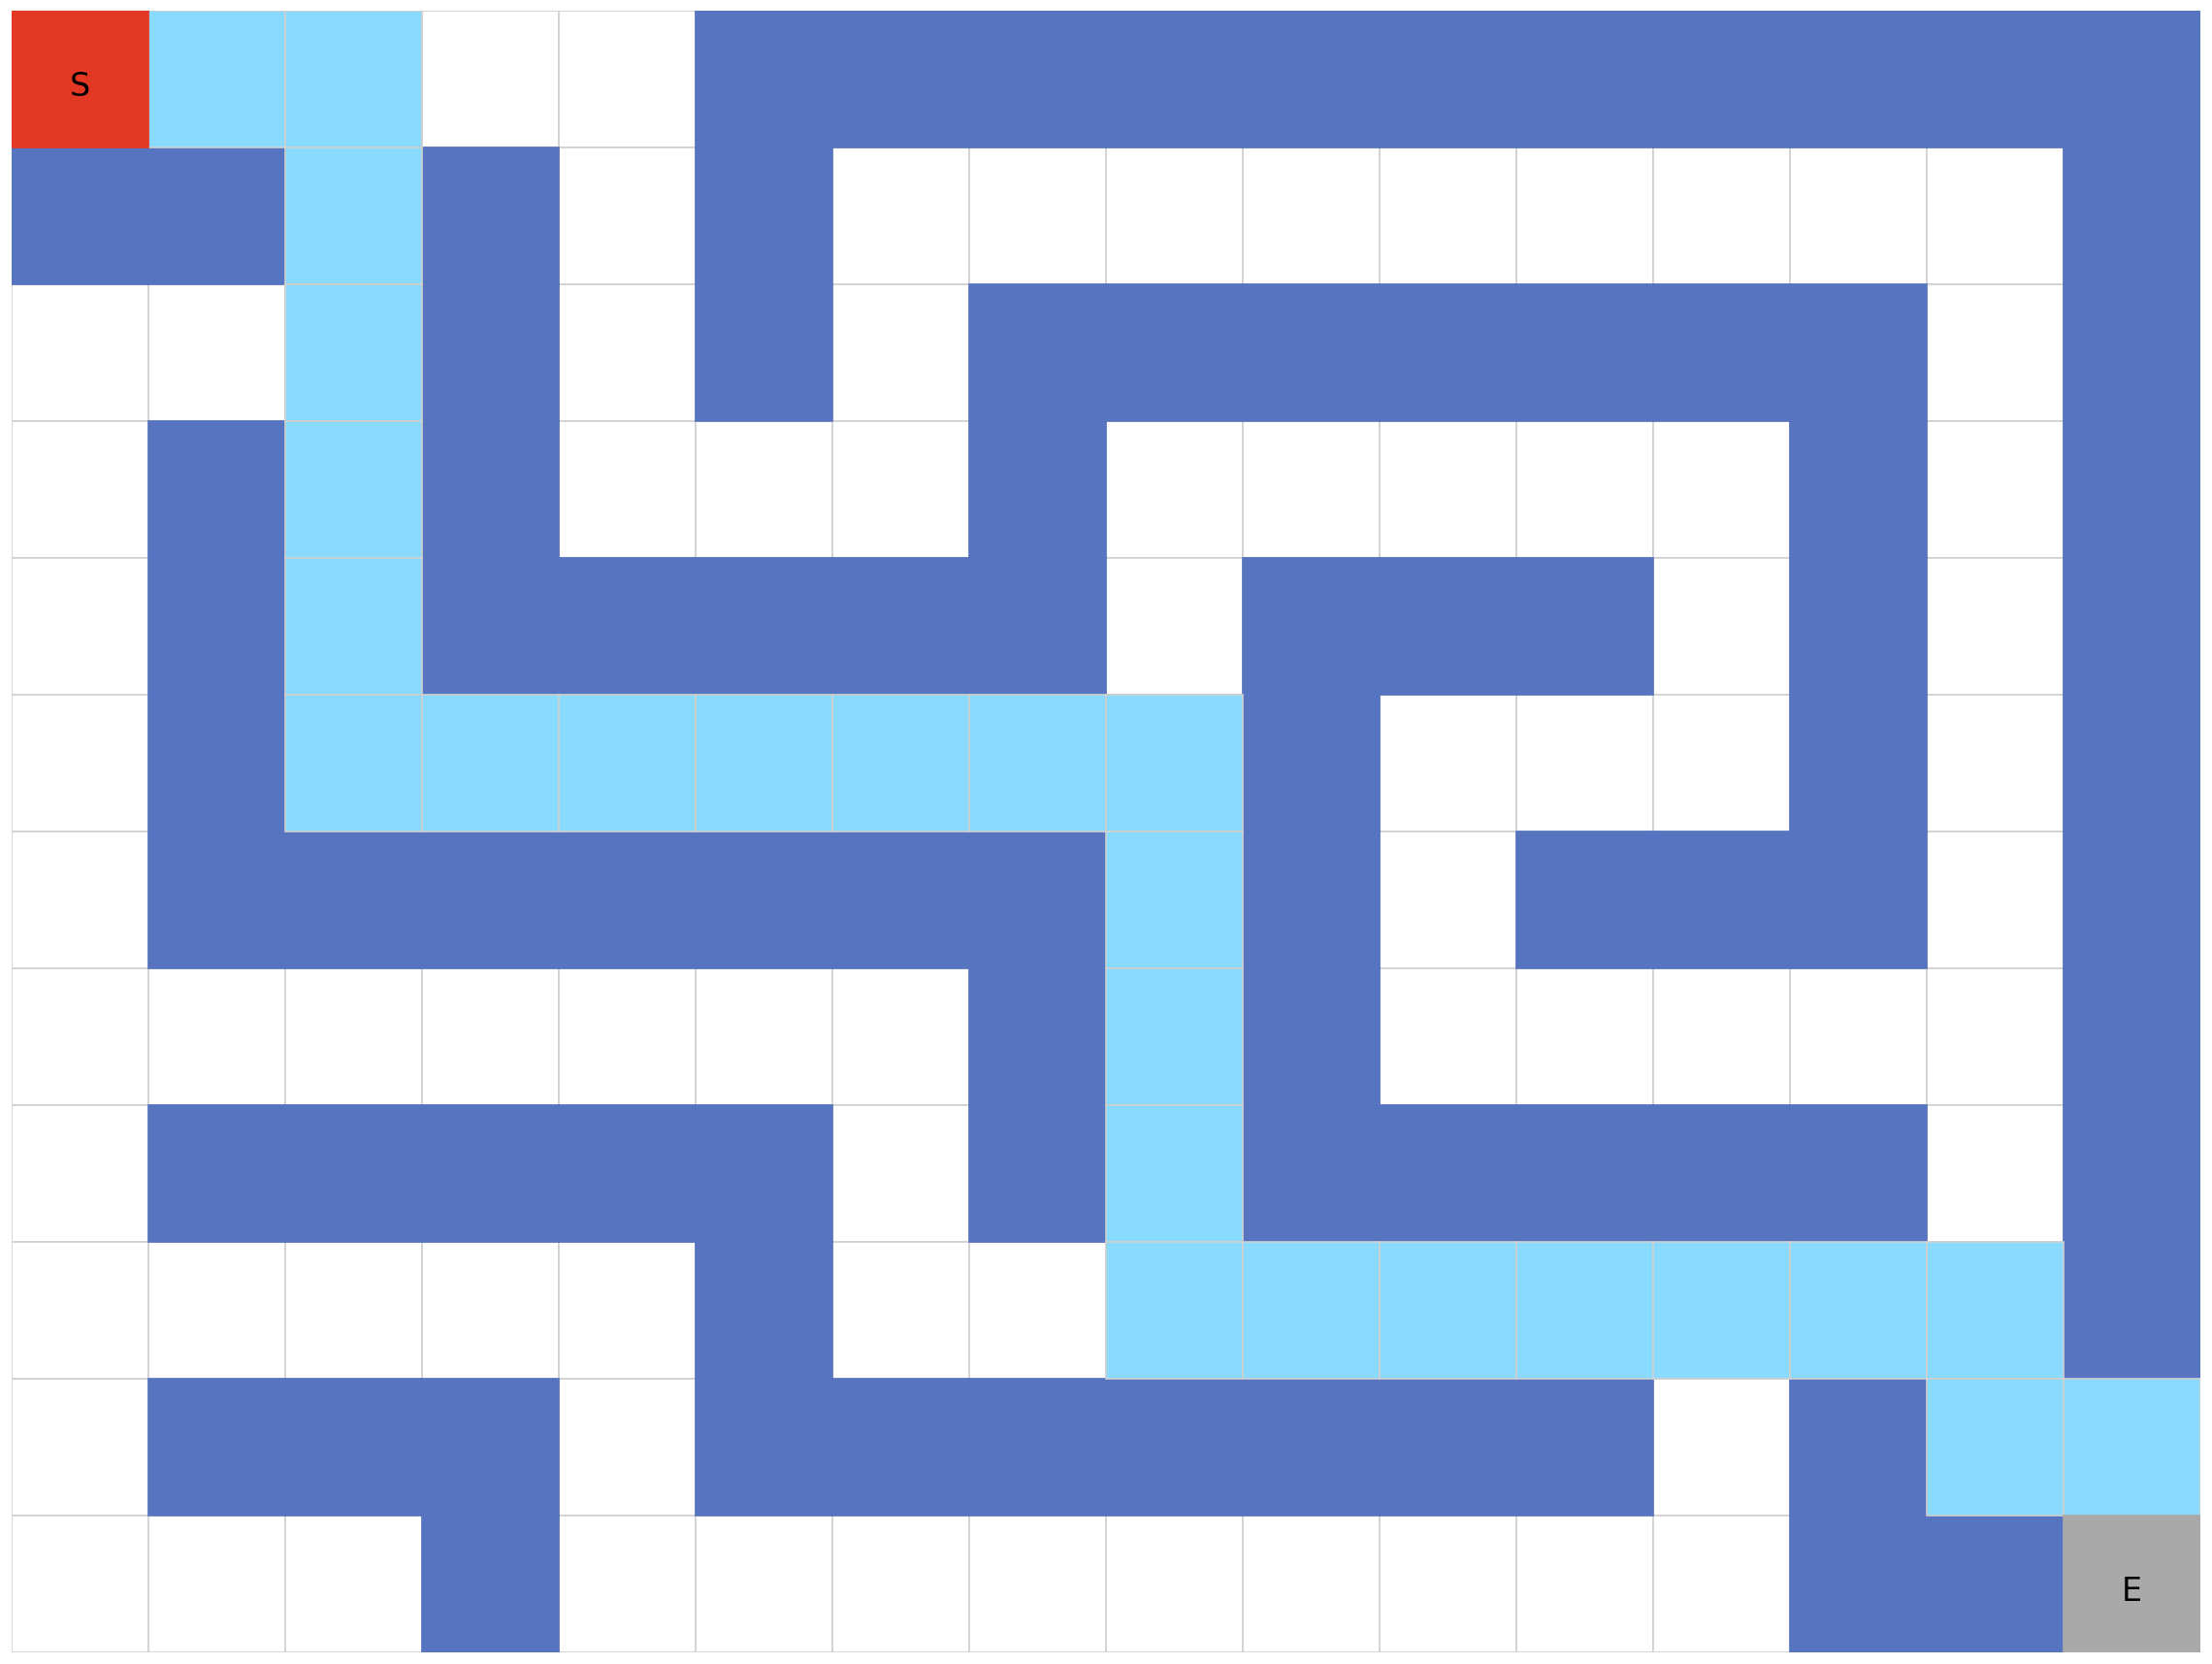

In [78]:
def animate_dqn_path(grid, start, goal, path, delay=0.15):
    """按 DQN 生成的 path 逐步展示行走过程。"""
    if path is None or len(path) == 0:
        print("DQN 路径为空，无法可视化")
        return

    # 逐步显示路径前缀，模拟智能体一步步移动
    for i in range(1, len(path) + 1):
        clear_output(wait=True)
        draw_grid(
            grid,
            start=start,
            goal=goal,
            path=path[:i],
        )
        time.sleep(delay)


# 使用(3)训练好的模型生成的 dqn_path 进行可视化
animate_dqn_path(rl_grid, rl_start, rl_goal, dqn_path, delay=0.12)

Dijsktra 路径搜索可视化

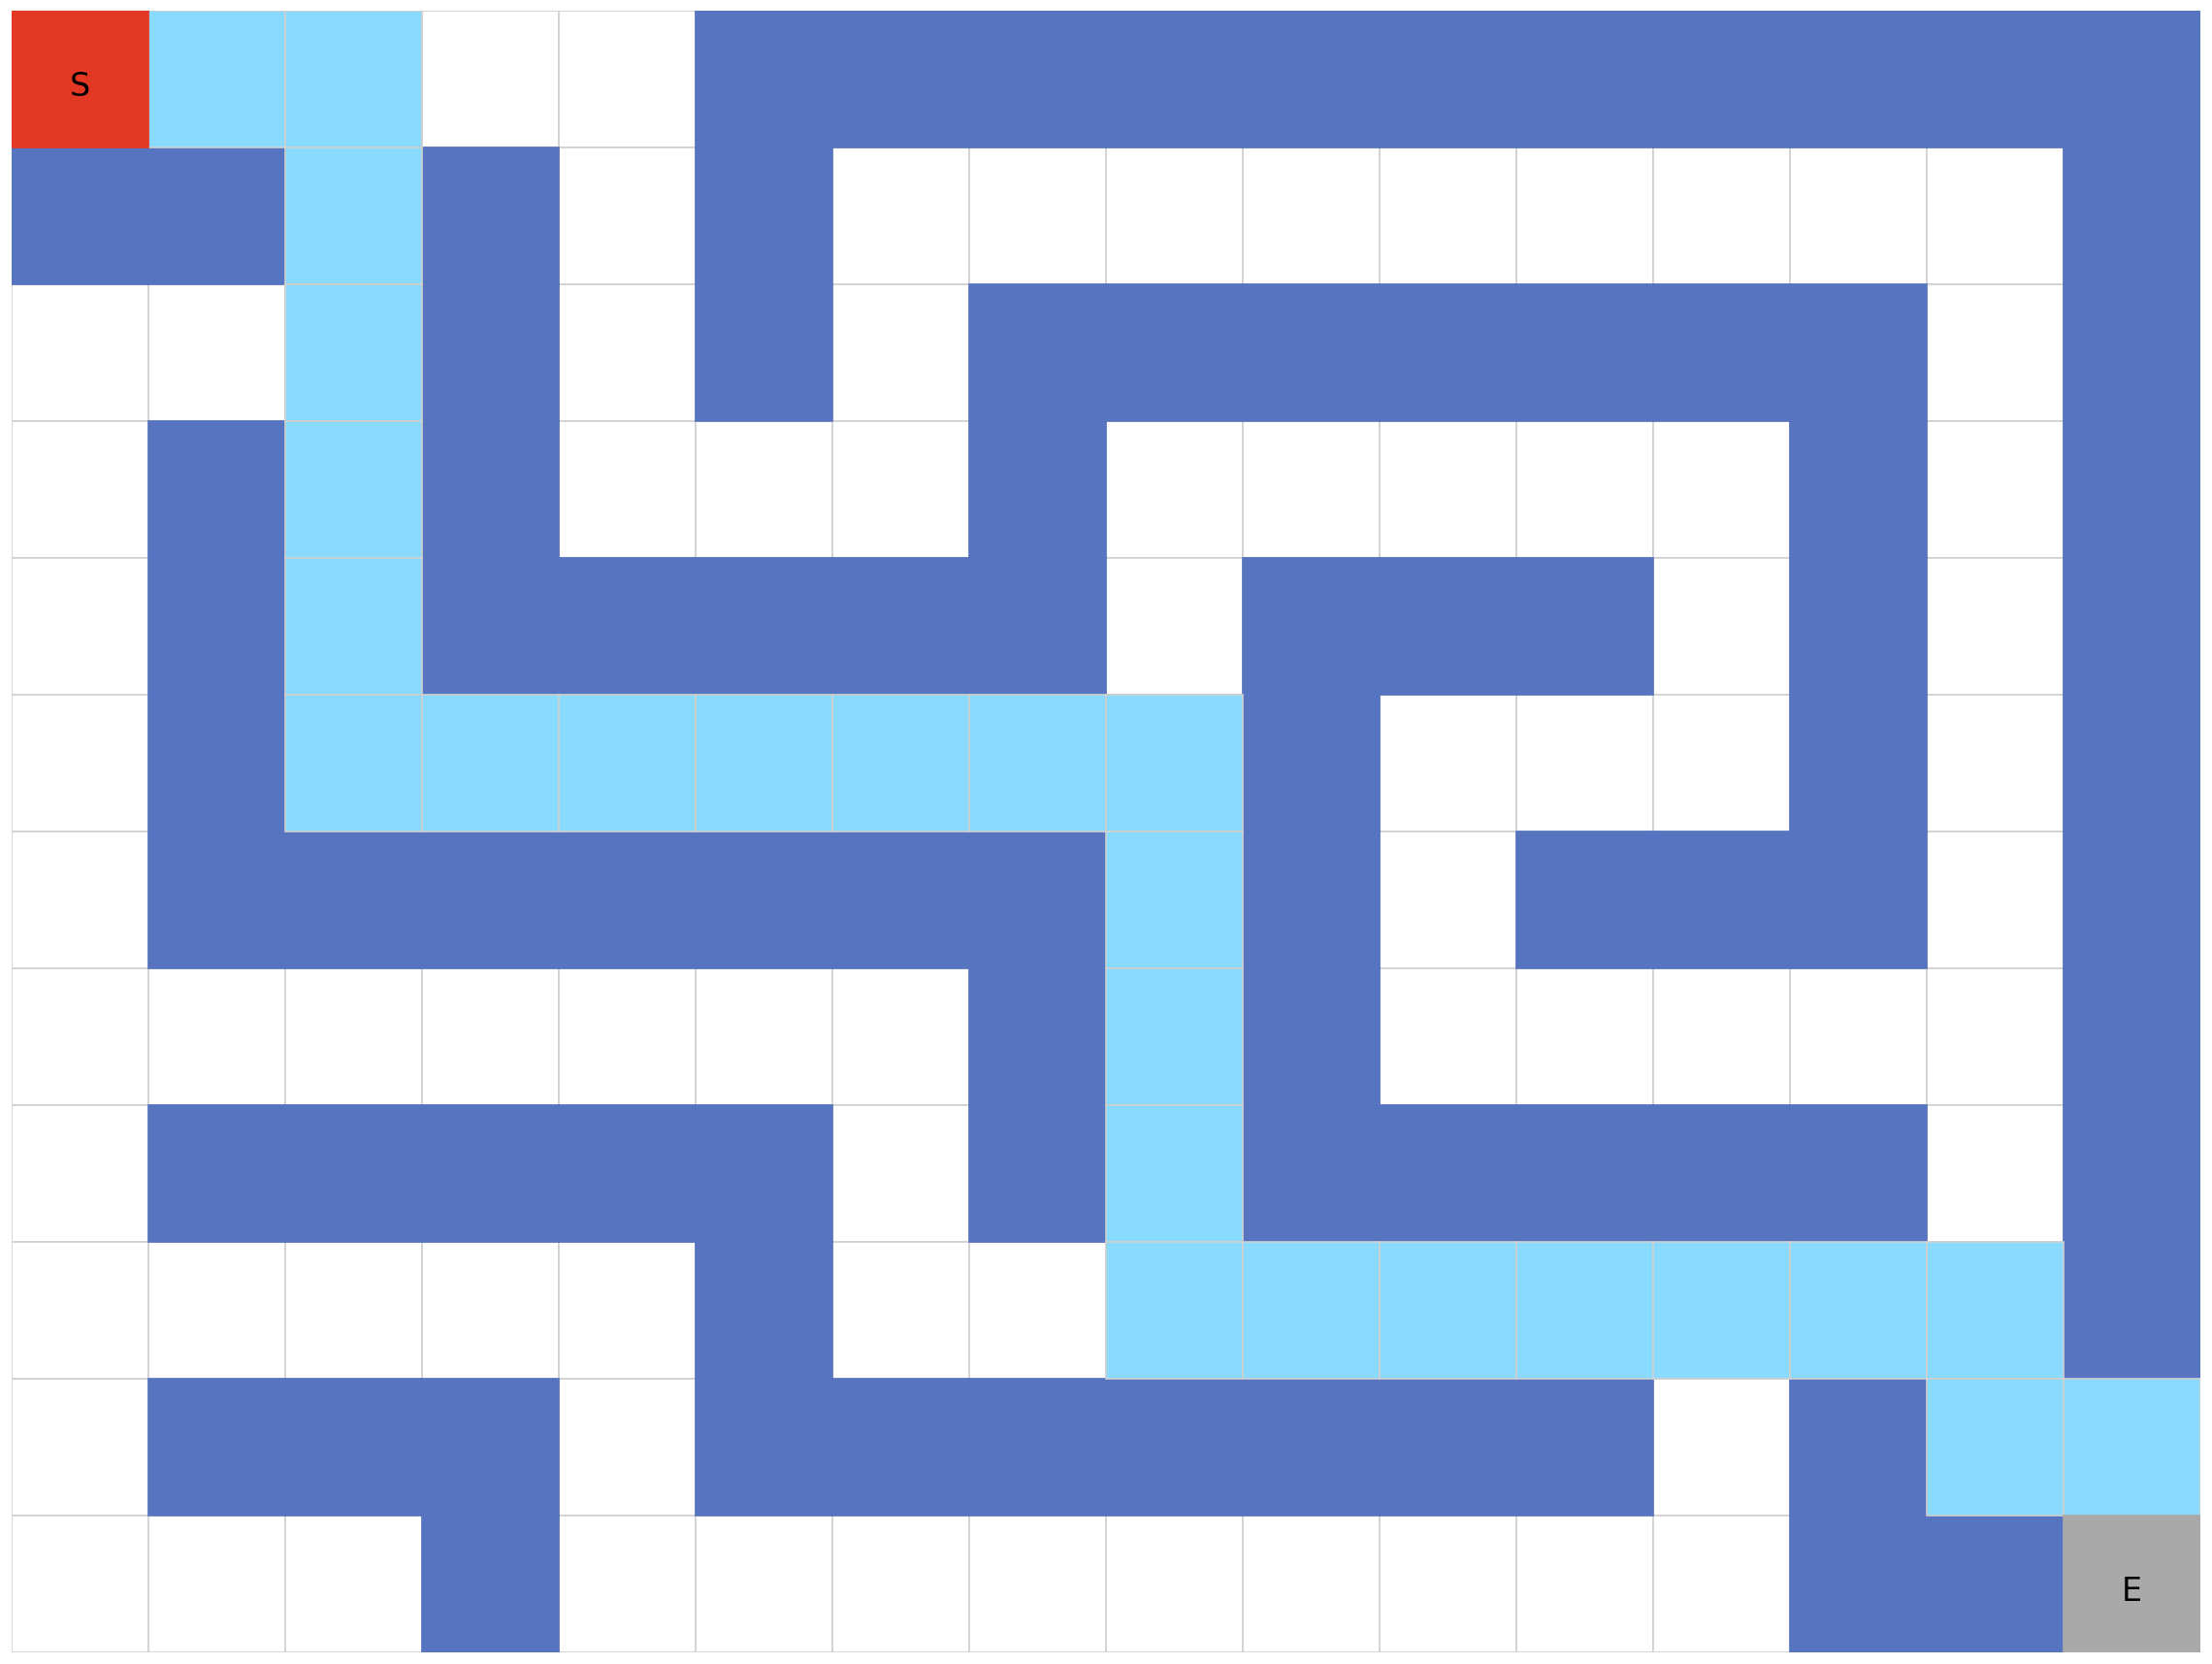

In [21]:
animate_search(
    rl_grid,
    rl_start,
    rl_goal,
    dijkstra_visited,
    dijkstra_path,
    delay=0.01
)